# Kampala Air Quality and TB Analysis - Full Dataset Pipeline


# Step 1: Load and Process Data


In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import geopandas as gpd
from datetime import date
from pathlib import Path
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [31]:
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

main_df = pd.merge(
    clim_df,
    plo_df,
    left_on=['epi_year', 'epi_week'],
    right_on=['year', 'week'],
    how='inner'
)

drop_cols = ['year', 'week']
main_df.drop(columns=drop_cols, inplace=True)

# Function to get the last day (Sunday) of each ISO week
def get_last_day_of_week(year, week):
    return date.fromisocalendar(int(year), int(week), 7)

# Apply function to create a proper date column
main_df['date'] = main_df.apply(
    lambda row: get_last_day_of_week(row['epi_year'], row['epi_week']),
    axis=1
)

main_df['date'] = pd.to_datetime(main_df['date'])   # ensure datetime dtype

# Extract the last date (Sunday) from periodname
resp_df['date'] = resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')
resp_df['date'] = pd.to_datetime(resp_df['date'], errors='coerce')

# Keep ALL columns (not just TB)
resp_df = resp_df.drop(columns=['periodname'])  # drop only the text period column


In [32]:

# --- Merge climate + TB + other health indicators ---
merged_df = pd.merge(main_df, resp_df, on='date', how='inner')


# Rename climate columns to match processor expectations
rename_map = {
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'ILD deaths': 'ILD_deaths',
    'Severe pneumonia under 5 Cases': 'pneumonia_u5',
    'Severe pneumonia under 5 deaths': 'pneumonia_u5_deaths',
    'SARI Cases': 'SARI',
    'SARI Deaths': 'SARI_deaths'
}

merged_df.rename(columns=rename_map, inplace=True)

In [33]:
# Select the columns you want to impute
cols_to_impute = ['pm2_5', 'avgtemp', 'avghumidity', 'TB']

imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent'
merged_df[cols_to_impute] = imputer.fit_transform(merged_df[cols_to_impute])

# Save merged dataset
merged_df.to_csv('data/merged_climate_tb_data.csv', index=False)

In [34]:
# ## Step 1: Load and Process Data

# %%
# Initialize data processor
processor = SimplifiedDataProcessor(data_dir='../data')

# Load the merged data
data = processor.load_data('./data/merged_climate_tb_data.csv')
print(f"✓ Loaded data: {len(data)} records")

INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_tb_data.csv
INFO:simplified_data_processor:Loaded 248 records
INFO:simplified_data_processor:Data processing complete: 248 records


✓ Loaded data: 248 records


In [35]:
# Add lag features and rolling averages
processed_data = processor.add_lag_features()

# Add extra engineered features so they pass through the same initial pipeline
processed_data['date'] = pd.to_datetime(processed_data['date'], errors='coerce', dayfirst=True)
processed_data['temp_humidity_interaction'] = processed_data['avgtemp'] * processed_data['avghumidity']
processed_data['temp_sat_gap'] = processed_data['avgtemp'] - processed_data.get('avgtemp_sat', processed_data['avgtemp'])
processed_data['humidity_sat_gap'] = processed_data['avghumidity'] - processed_data.get('humidity_sat', processed_data['avghumidity'])
processed_data['precip_rolling_4'] = processed_data['precip'].rolling(window=4, min_periods=1).mean()
processed_data['windspeed_rolling_4'] = processed_data['windspeed'].rolling(window=4, min_periods=1).mean()

for window in [7, 14, 30]:
    processed_data[f'pm25_trailing_ma_{window}'] = processed_data['pm2_5'].rolling(window=window, min_periods=1).mean()
    processed_data[f'tb_trailing_ma_{window}'] = processed_data['TB'].rolling(window=window, min_periods=1).mean()
    processed_data[f'pm25_leading_ma_{window}'] = (
        processed_data['pm2_5'].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
    )
    processed_data[f'tb_leading_ma_{window}'] = (
        processed_data['TB'].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
    )

processed_data['pm25_temp_ratio'] = processed_data['pm2_5'] / (processed_data['avgtemp'].abs() + 1)
processed_data['pm25_humidity_ratio'] = processed_data['pm2_5'] / (processed_data['avghumidity'].abs() + 1)
processed_data['tb_pct_change_1'] = processed_data['TB'].pct_change().replace([np.inf, -np.inf], np.nan)
processed_data['tb_diff_1'] = processed_data['TB'].diff()
processed_data['sin_week'] = np.sin(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['cos_week'] = np.cos(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['sin_month'] = np.sin(2 * np.pi * processed_data['month'] / 12)
processed_data['cos_month'] = np.cos(2 * np.pi * processed_data['month'] / 12)

print(f"✓ Added features: {processed_data.shape[1]} total columns")


INFO:simplified_data_processor:Added lag features and rolling averages


✓ Added features: 80 total columns


In [36]:
# Get summary statistics
summary = processor.get_summary_statistics()
print("\nData Summary:")
print(f"- Date range: {summary['date_range']}")
print(f"- Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"- Total TB cases: {summary['tb_statistics']['total_cases']}")
print(f"- PM2.5-TB correlation: {summary['correlation_pm25_tb']:.3f}")



Data Summary:
- Date range: 2020-01-05 00:00:00 to 2024-12-15 00:00:00
- Average PM2.5: 39.28 μg/m³
- Total TB cases: 158287.77142857143
- PM2.5-TB correlation: -0.017


In [37]:
# Display first few rows including diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
preview_cols = [
    'date', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + disease_cols + [
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]
preview_cols = [col for col in preview_cols if col in processed_data.columns]
processed_data[preview_cols].head(10)


,date,pm2_5,avgtemp,avghumidity,windspeed,precip,TB,ILI,ILD_deaths,pneumonia_u5,...,precip_rolling_4,windspeed_rolling_4,pm25_temp_ratio,pm25_humidity_ratio,tb_pct_change_1,tb_diff_1,sin_week,cos_week,sin_month,cos_month
0,2020-01-05,43.77,24.45,72.79,2.08,2.52,7.0,NaN,NaN,16,...,2.520000,2.080000,1.719843,0.593170,NaN,NaN,0.120537,0.992709,0.500000,8.660254e-01
1,2020-01-12,68.62,23.01,75.92,2.69,12.99,30.0,NaN,NaN,15,...,7.755000,2.385000,2.857976,0.892096,3.285714,23.0,0.239316,0.970942,0.500000,8.660254e-01
2,2020-01-19,72.99,24.49,70.07,2.18,14.48,40.0,NaN,NaN,4,...,9.996667,2.316667,2.863476,1.027016,0.333333,10.0,0.354605,0.935016,0.500000,8.660254e-01
3,2020-01-26,90.92,24.11,54.71,3.01,5.51,37.0,NaN,NaN,16,...,8.875000,2.490000,3.620868,1.632023,-0.075000,-3.0,0.464723,0.885456,0.500000,8.660254e-01
4,2020-02-02,35.29,21.79,83.86,1.91,66.83,343.0,37.0,NaN,39,...,24.952500,2.447500,1.548486,0.415861,8.270270,306.0,0.568065,0.822984,0.866025,5.000000e-01
5,2020-02-09,44.04,22.47,81.82,2.00,86.25,173.0,14.0,NaN,38,...,43.267500,2.275000,1.876438,0.531756,-0.495627,-170.0,0.663123,0.748511,0.866025,5.000000e-01
6,2020-02-16,61.22,24.49,68.12,2.42,1.91,302.0,32.0,NaN,85,...,40.125000,2.335000,2.401726,0.885706,0.745665,129.0,0.748511,0.663123,0.866025,5.000000e-01
7,2020-02-23,40.34,24.66,76.43,2.08,15.50,265.0,52.0,NaN,78,...,42.622500,2.102500,1.572097,0.520987,-0.122517,-37.0,0.822984,0.568065,0.866025,5.000000e-01
8,2020-03-01,45.60,24.15,78.90,1.91,24.74,340.0,47.0,NaN,112,...,32.100000,2.102500,1.813121,0.570713,0.283019,75.0,0.885456,0.464723,1.000000,6.123234e-17
9,2020-03-08,47.95,23.45,83.80,2.19,34.51,338.0,7.0,3.0,125,...,19.165000,2.150000,1.961145,0.565448,-0.005882,-2.0,0.935016,0.354605,1.000000,6.123234e-17


## Step 2: Exploratory Data Analysis


### 2.1 Time Series Overview


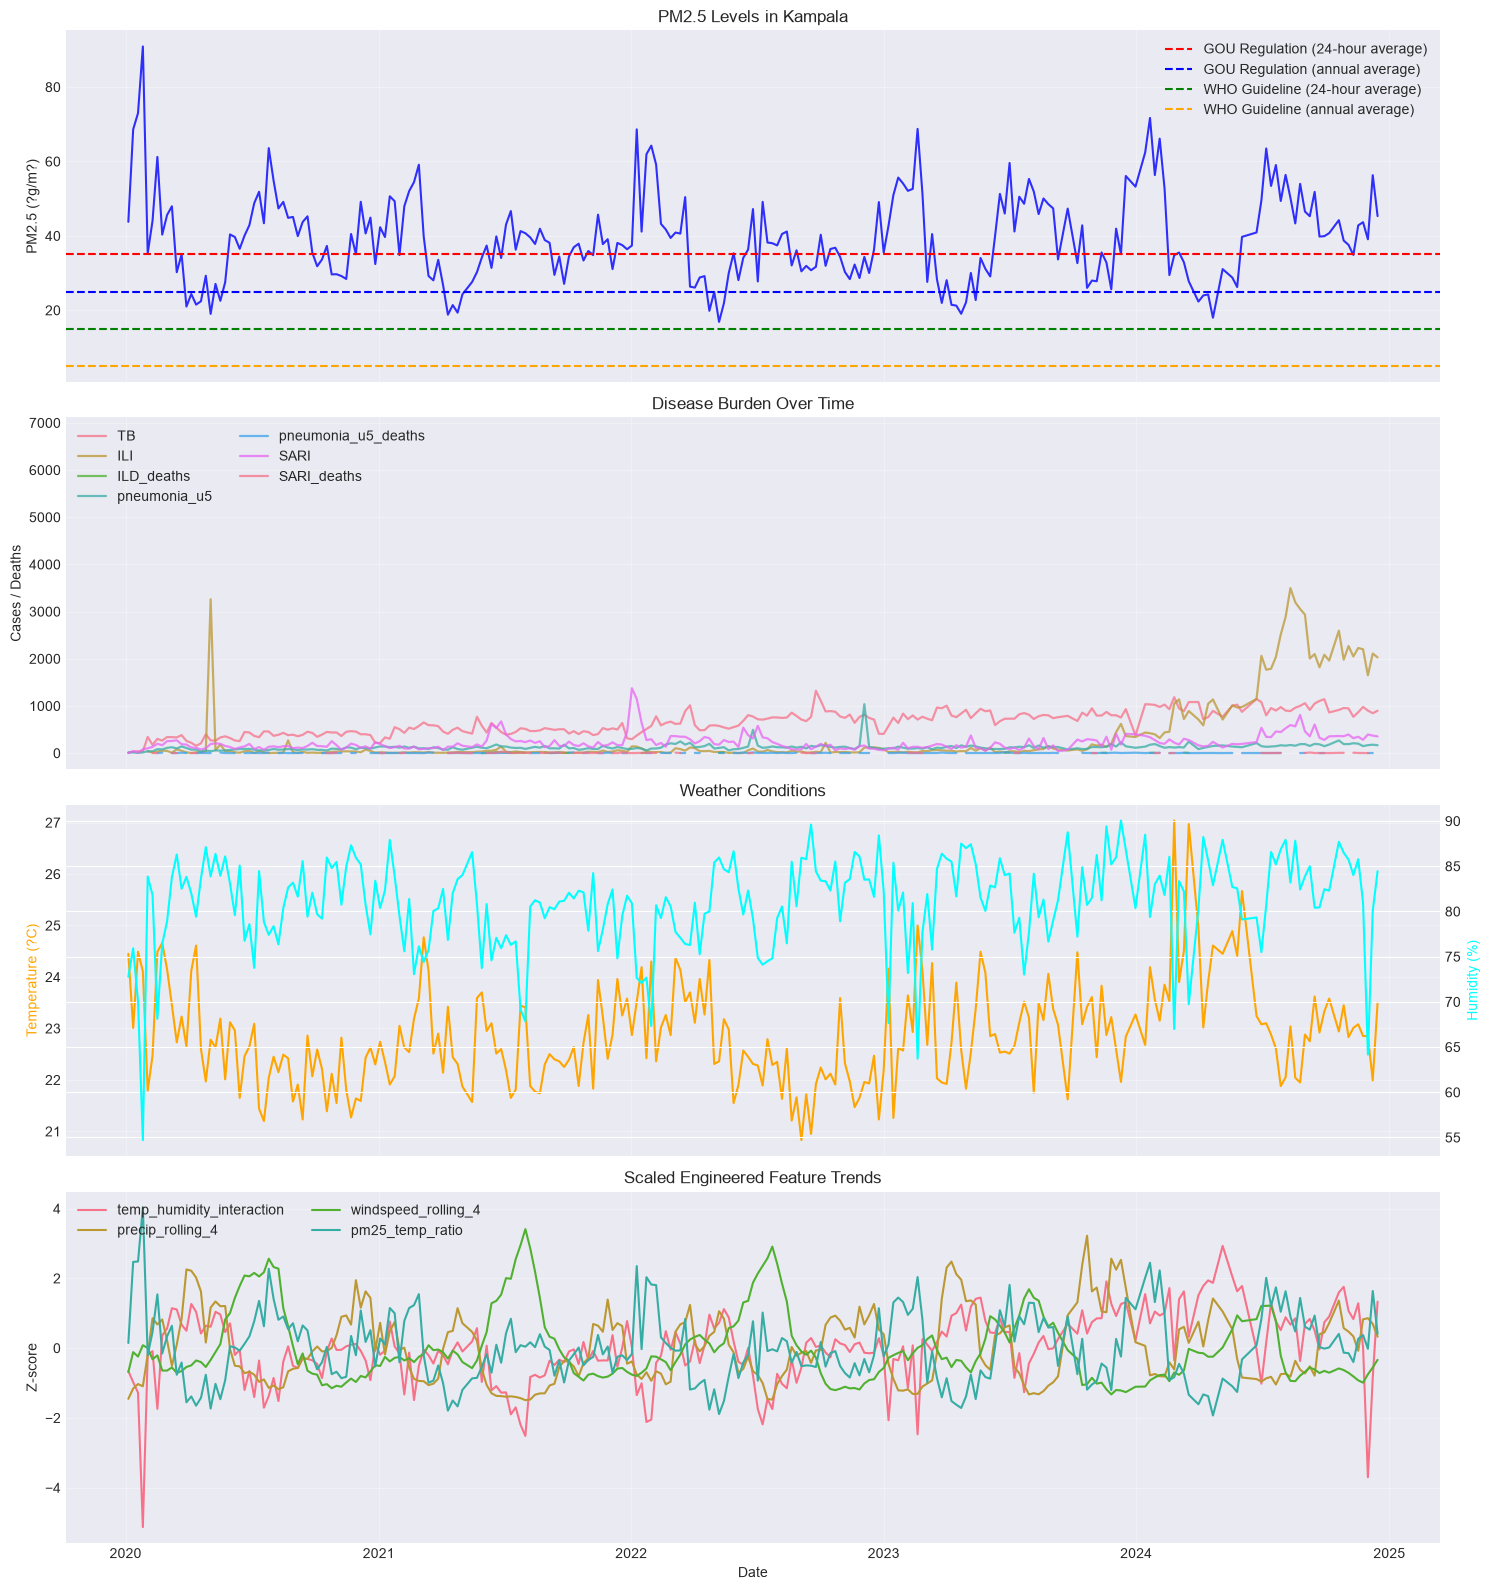

In [38]:
# Time series overview for air quality, diseases, and weather
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes[0].plot(processed_data['date'], processed_data['pm2_5'], color='blue', alpha=0.8)
axes[0].axhline(y=35, color='red', linestyle='--', label='GOU Regulation (24-hour average)')
axes[0].axhline(y=25, color='blue', linestyle='--', label='GOU Regulation (annual average)')
axes[0].axhline(y=15, color='green', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (annual average)')
axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (?g/m?)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for disease in disease_cols:
    axes[1].plot(processed_data['date'], processed_data[disease], alpha=0.75, linewidth=1.6, label=disease)
axes[1].set_title('Disease Burden Over Time')
axes[1].set_ylabel('Cases / Deaths')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(True, alpha=0.3)

ax2_twin = axes[2].twinx()
axes[2].plot(processed_data['date'], processed_data['avgtemp'], color='orange', label='Temperature')
ax2_twin.plot(processed_data['date'], processed_data['avghumidity'], color='cyan', label='Humidity')
axes[2].set_title('Weather Conditions')
axes[2].set_ylabel('Temperature (?C)', color='orange')
ax2_twin.set_ylabel('Humidity (%)', color='cyan')
axes[2].grid(True, alpha=0.3)

engineered_plot_cols = [
    col for col in ['temp_humidity_interaction', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio']
    if col in processed_data.columns
]
engineered_scaled = processed_data[engineered_plot_cols].copy()
for col in engineered_plot_cols:
    col_std = engineered_scaled[col].std()
    if pd.notna(col_std) and col_std != 0:
        engineered_scaled[col] = (engineered_scaled[col] - engineered_scaled[col].mean()) / col_std
    else:
        engineered_scaled[col] = 0
for col in engineered_plot_cols:
    axes[3].plot(processed_data['date'], engineered_scaled[col], linewidth=1.5, label=col)
axes[3].set_title('Scaled Engineered Feature Trends')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', ncol=2)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.2 Correlation Analysis


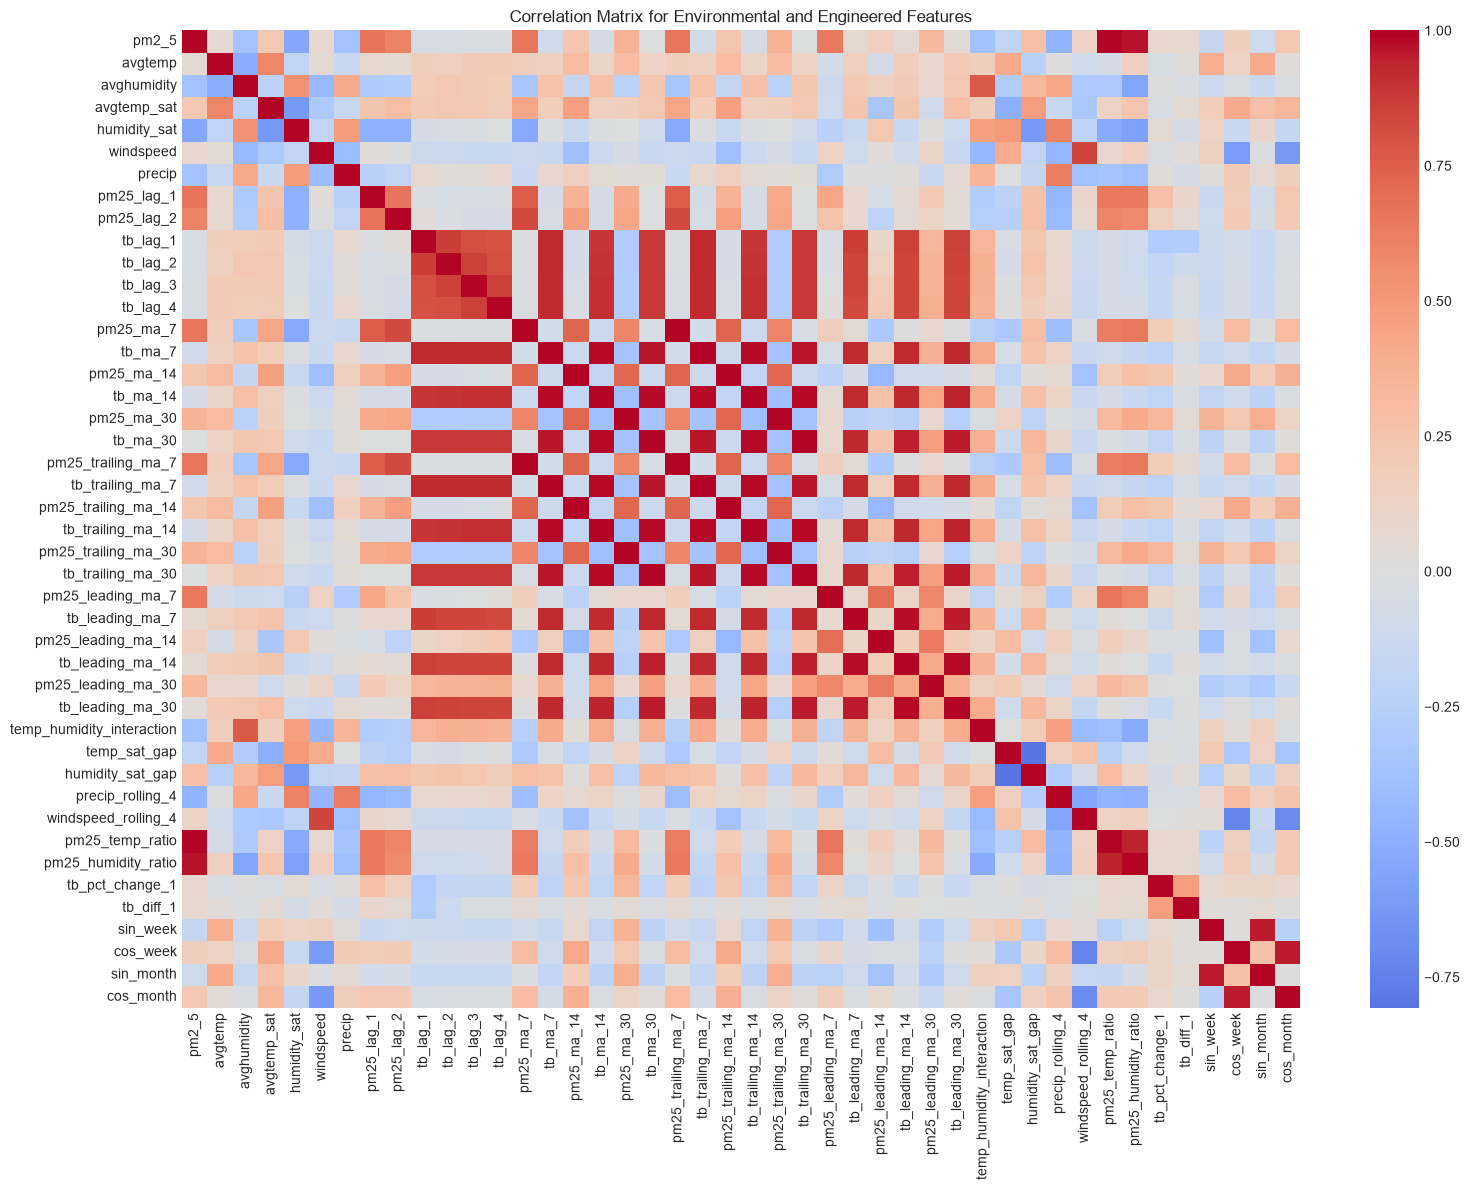

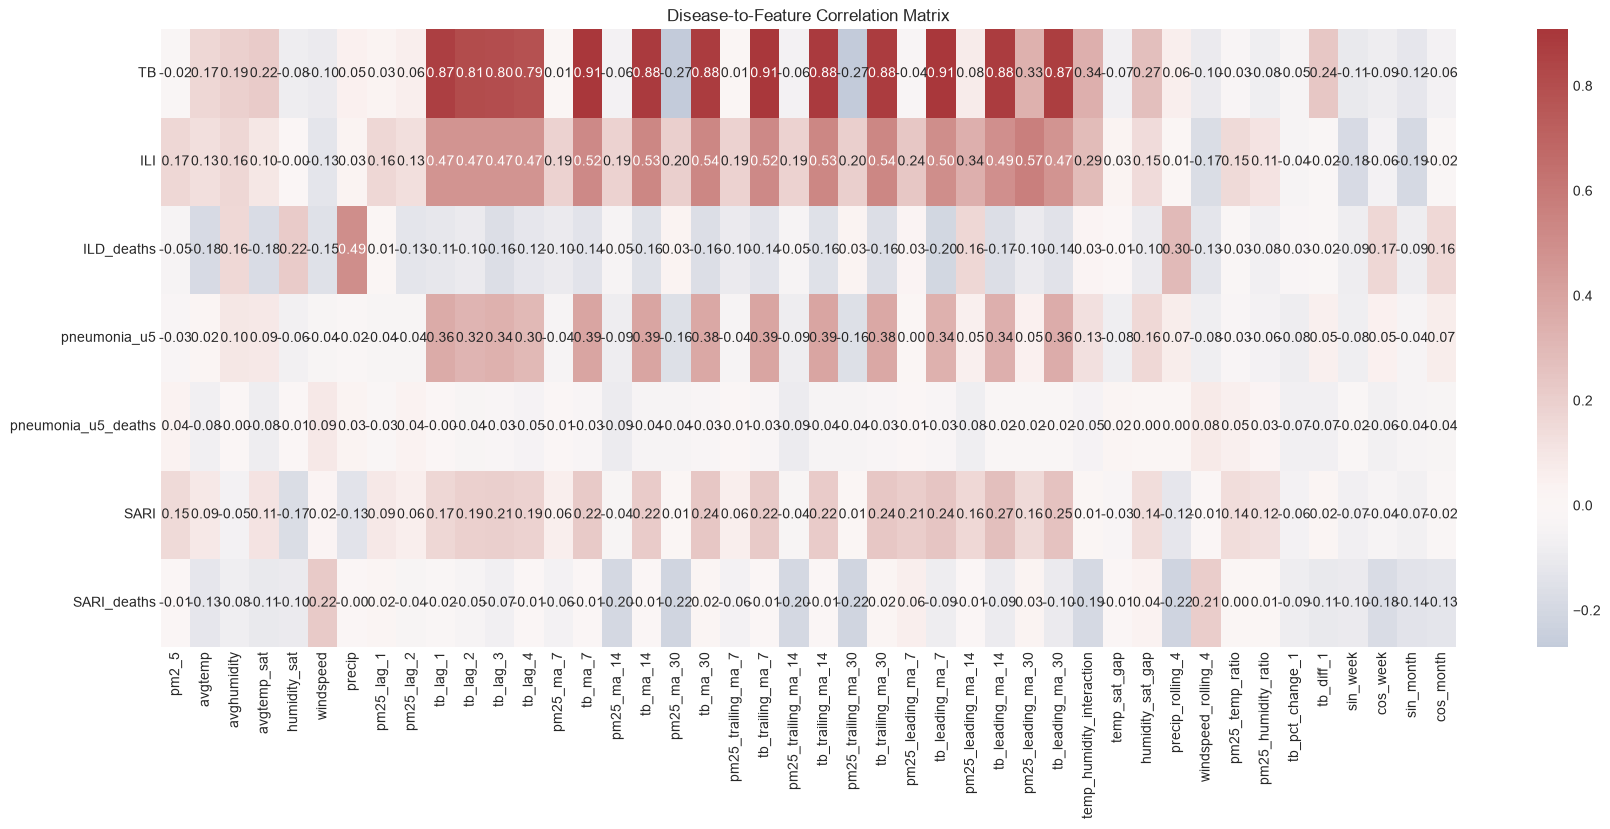

In [39]:
# Correlation analysis across diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
        'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
        'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
        'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

feature_corr_matrix = processed_data[feature_analysis_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Environmental and Engineered Features')
plt.tight_layout()
plt.show()

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
plt.figure(figsize=(18, max(4, len(disease_cols) * 1.2)))
sns.heatmap(disease_feature_corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Disease-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.3 Disease-Level Feature Ranking


In [40]:
# Disease-level feature ranking and pairwise relationships
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
        'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
        'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
        'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = (
    disease_feature_corr.abs()
    .stack()
    .reset_index(name='abs_correlation')
    .rename(columns={'level_0': 'disease', 'level_1': 'feature'})
    .sort_values(['disease', 'abs_correlation'], ascending=[True, False])
    .groupby('disease')
    .head(5)
)
strongest_links['correlation'] = strongest_links.apply(
    lambda row: disease_feature_corr.loc[row['disease'], row['feature']],
    axis=1
)
print('Top 5 absolute correlations per disease')
print(strongest_links[['disease', 'feature', 'correlation', 'abs_correlation']].to_string(index=False))

summary_stats = processed_data[disease_cols + feature_analysis_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
summary_stats.head(20)


Top 5 absolute correlations per disease
            disease             feature  correlation  abs_correlation
         ILD_deaths              precip     0.493361         0.493361
         ILD_deaths    precip_rolling_4     0.296231         0.296231
         ILD_deaths        humidity_sat     0.219189         0.219189
         ILD_deaths     tb_leading_ma_7    -0.204881         0.204881
         ILD_deaths             avgtemp    -0.183328         0.183328
                ILI  pm25_leading_ma_30     0.571174         0.571174
                ILI            tb_ma_30     0.537401         0.537401
                ILI   tb_trailing_ma_30     0.537401         0.537401
                ILI            tb_ma_14     0.531085         0.531085
                ILI   tb_trailing_ma_14     0.531085         0.531085
               SARI    tb_leading_ma_14     0.268701         0.268701
               SARI    tb_leading_ma_30     0.254107         0.254107
               SARI     tb_leading_ma_7     0.2428

,mean,std,min,max
TB,638.257143,251.800953,7.0,1321.0
ILI,339.95082,724.514583,1.0,3498.0
ILD_deaths,132.125,904.011465,1.0,6775.0
pneumonia_u5,124.112903,75.613519,4.0,1037.0
pneumonia_u5_deaths,3.403141,3.289503,1.0,19.0
SARI,220.125,161.489839,1.0,1375.0
SARI_deaths,3.95614,4.435158,1.0,31.0
pm2_5,39.280081,11.806612,16.87,90.92
avgtemp,22.851992,0.969116,20.83,27.04
avghumidity,80.956842,5.046416,54.71,90.06


### 2.4 PM2.5 vs Disease Scatter Plots


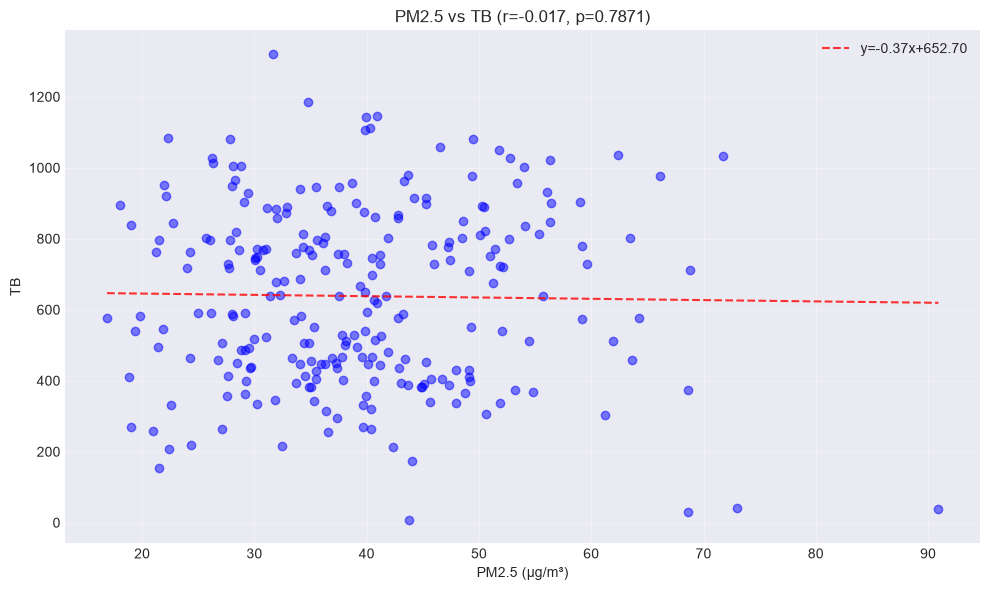

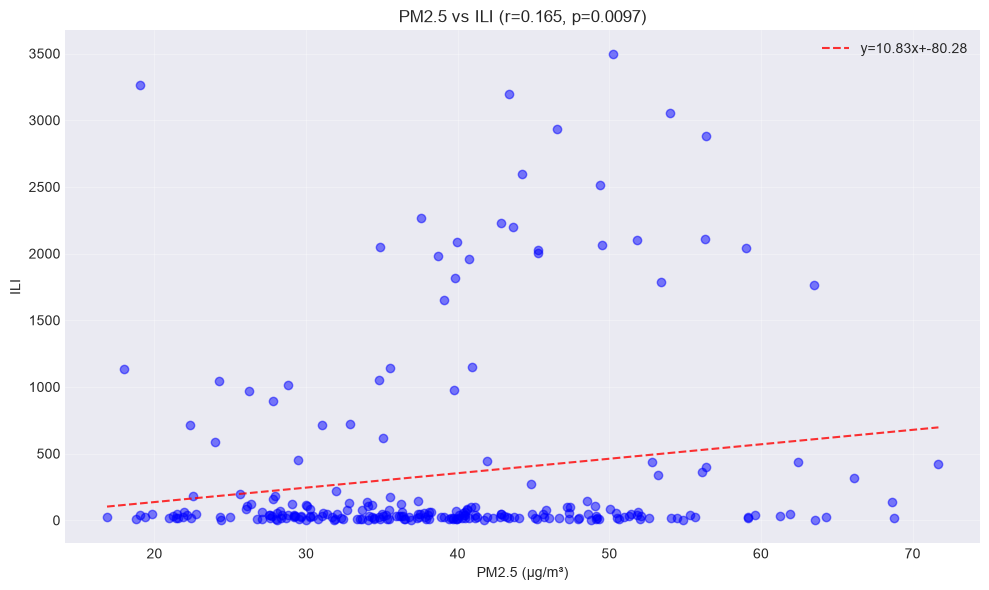

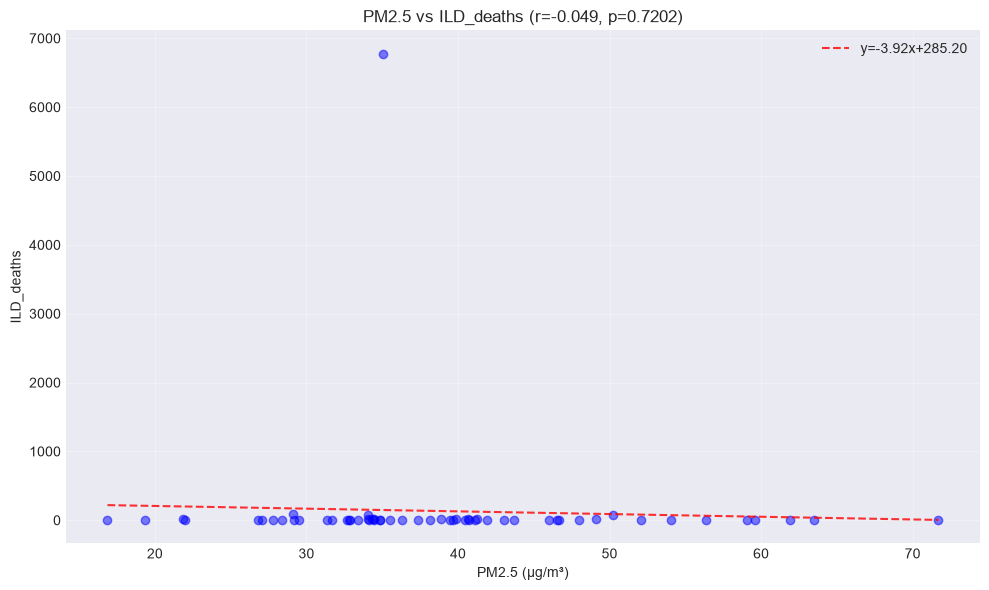

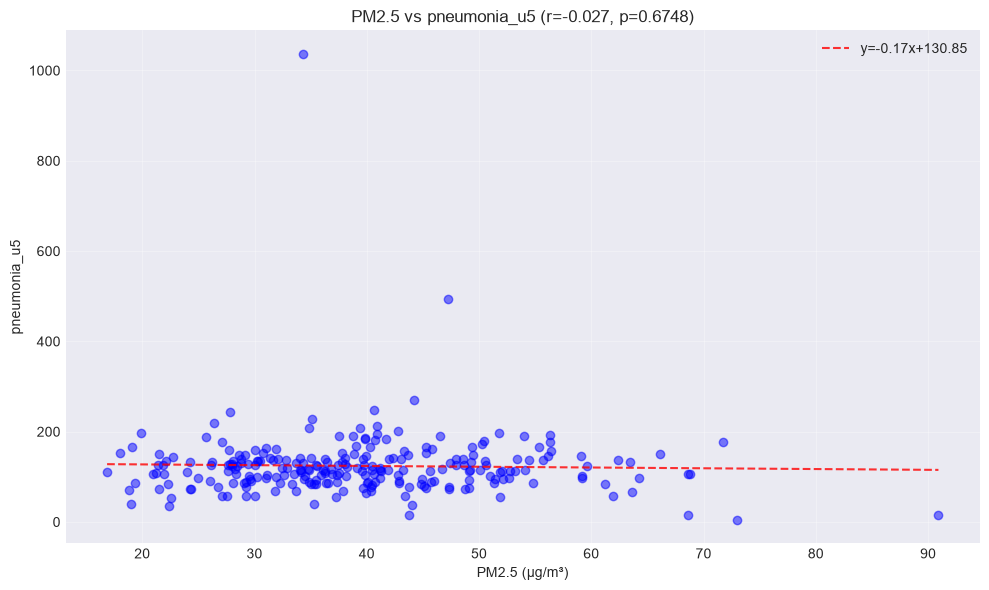

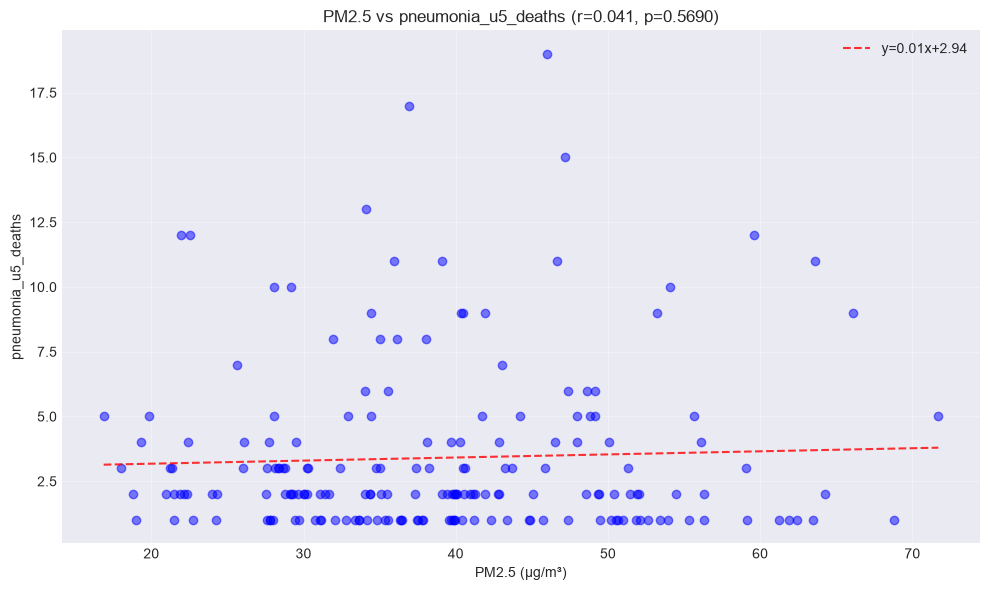

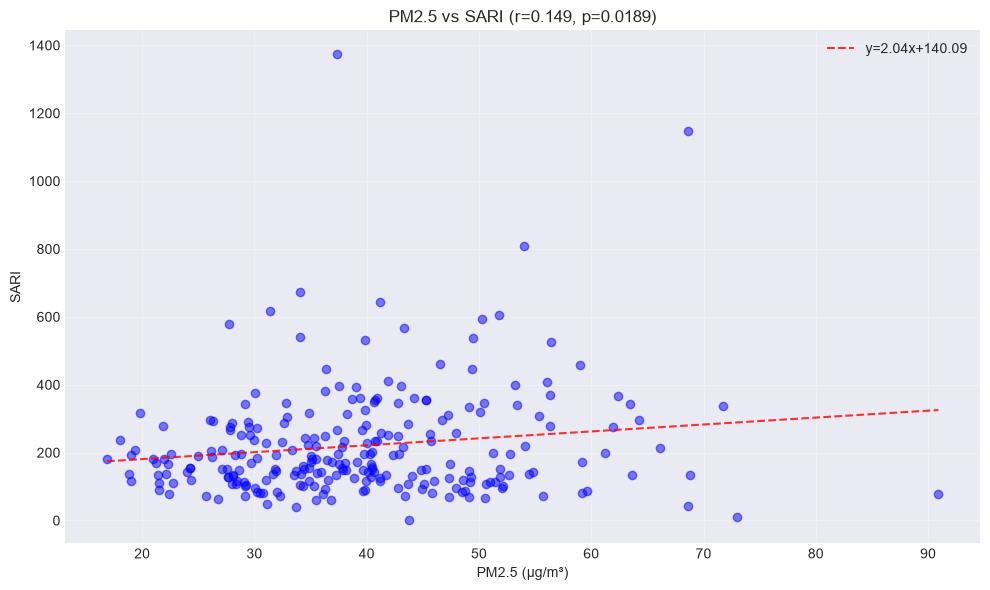

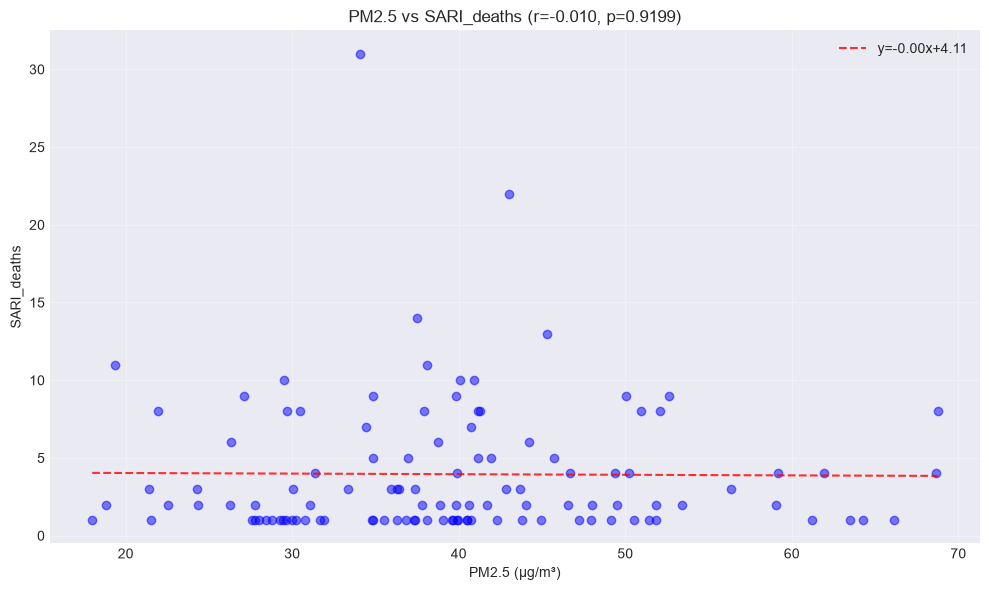

In [41]:
# PM2.5 vs disease scatter plots with regression lines
import scipy.stats as stats

disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths'] if col in processed_data.columns]

for disease in disease_cols:
    plot_data = processed_data[['pm2_5', disease]].dropna()
    if len(plot_data) < 2:
        print(f"Skipping {disease}: not enough non-null points for regression.")
        continue

    plt.figure(figsize=(10, 6))
    plt.scatter(plot_data['pm2_5'], plot_data[disease], alpha=0.5, color='blue')

    z = np.polyfit(plot_data['pm2_5'], plot_data[disease], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(plot_data['pm2_5'].to_numpy())
    plt.plot(x_sorted, p(x_sorted), 'r--', alpha=0.8, label=f'y={z[0]:.2f}x+{z[1]:.2f}')

    corr, p_value = stats.pearsonr(plot_data['pm2_5'], plot_data[disease])
    plt.title(f'PM2.5 vs {disease} (r={corr:.3f}, p={p_value:.4f})')
    plt.xlabel('PM2.5 (μg/m³)')
    plt.ylabel(disease)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### 2.5 Seasonal Analysis


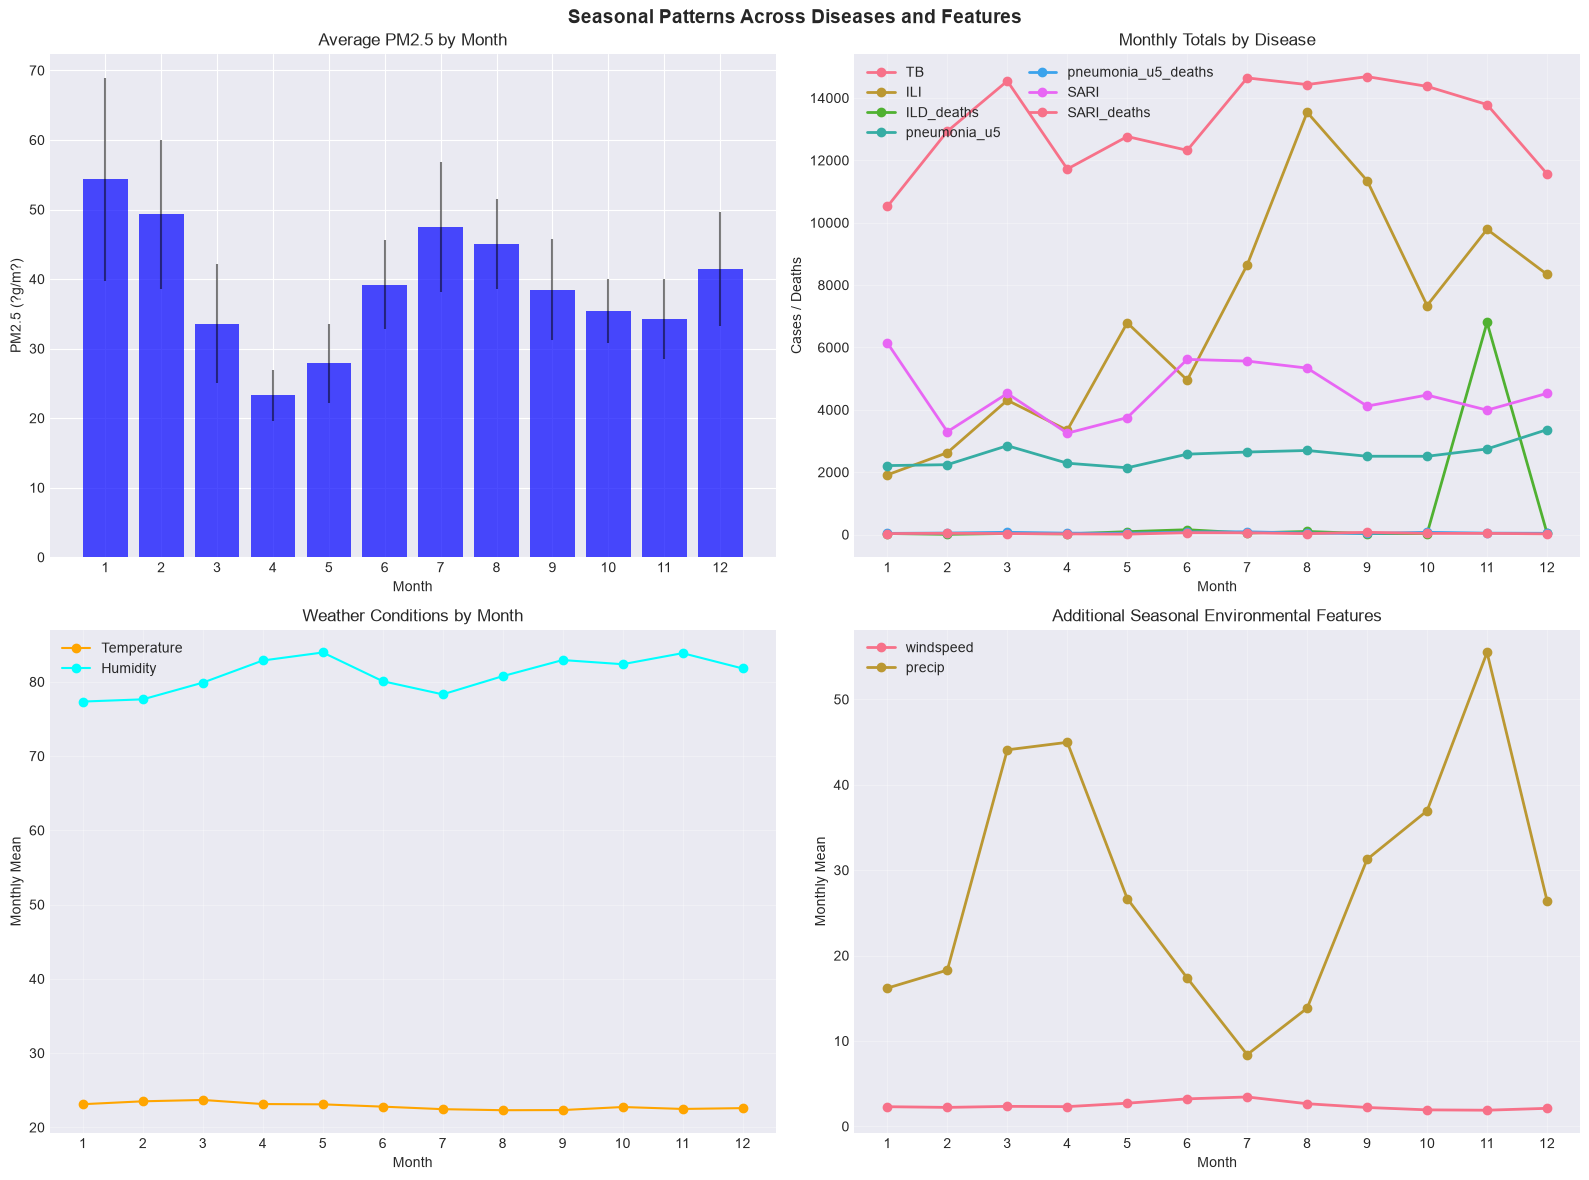

,TB,ILI,ILD_deaths,pneumonia_u5,pneumonia_u5_deaths,SARI,SARI_deaths
month,,,,,,,
1,10520.26,1914.0,33.0,2211,37.0,6143,31.0
2,12933.00,2626.0,7.0,2241,48.0,3297,40.0
3,14544.00,4307.0,34.0,2849,72.0,4524,31.0
4,11721.00,3346.0,21.0,2288,45.0,3250,22.0
5,12763.00,6790.0,92.0,2141,41.0,3750,12.0
6,12321.26,4954.0,155.0,2578,81.0,5616,61.0
7,14643.00,8647.0,49.0,2646,88.0,5563,57.0
8,14429.00,13540.0,99.0,2696,46.0,5338,29.0
9,14685.00,11349.0,30.0,2511,36.0,4119,72.0


In [42]:
# Monthly patterns across all diseases and key features
processed_data['month'] = processed_data['date'].dt.month
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
    if col in processed_data.columns
]
monthly_feature_cols = [
    col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in processed_data.columns
]
monthly_agg = {col: ['mean', 'std'] for col in monthly_feature_cols}
monthly_agg.update({col: ['mean', 'sum'] for col in disease_cols})
monthly_stats = processed_data.groupby('month').agg(monthly_agg).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(
    range(1, 13),
    monthly_stats['pm2_5']['mean'].values,
    yerr=monthly_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (?g/m?)')
axes[0, 0].set_xticks(range(1, 13))

for disease in disease_cols:
    axes[0, 1].plot(range(1, 13), monthly_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Monthly Totals by Disease')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='orange', label='Temperature')
axes[1, 0].plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='cyan', label='Humidity')
axes[1, 0].set_title('Weather Conditions by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Monthly Mean')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

seasonal_feature_cols = [
    col for col in ['windspeed', 'precip']
    if col in processed_data.columns
]
for col in seasonal_feature_cols:
    axes[1, 1].plot(range(1, 13), monthly_stats[col]['mean'].values, marker='o', linewidth=2, label=col)
axes[1, 1].set_title('Additional Seasonal Environmental Features')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Monthly Mean')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Seasonal Patterns Across Diseases and Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

monthly_disease_totals = monthly_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
monthly_disease_totals.columns = [col for col, _ in monthly_disease_totals.columns]
monthly_disease_totals


## Step 3: Spatial Analysis


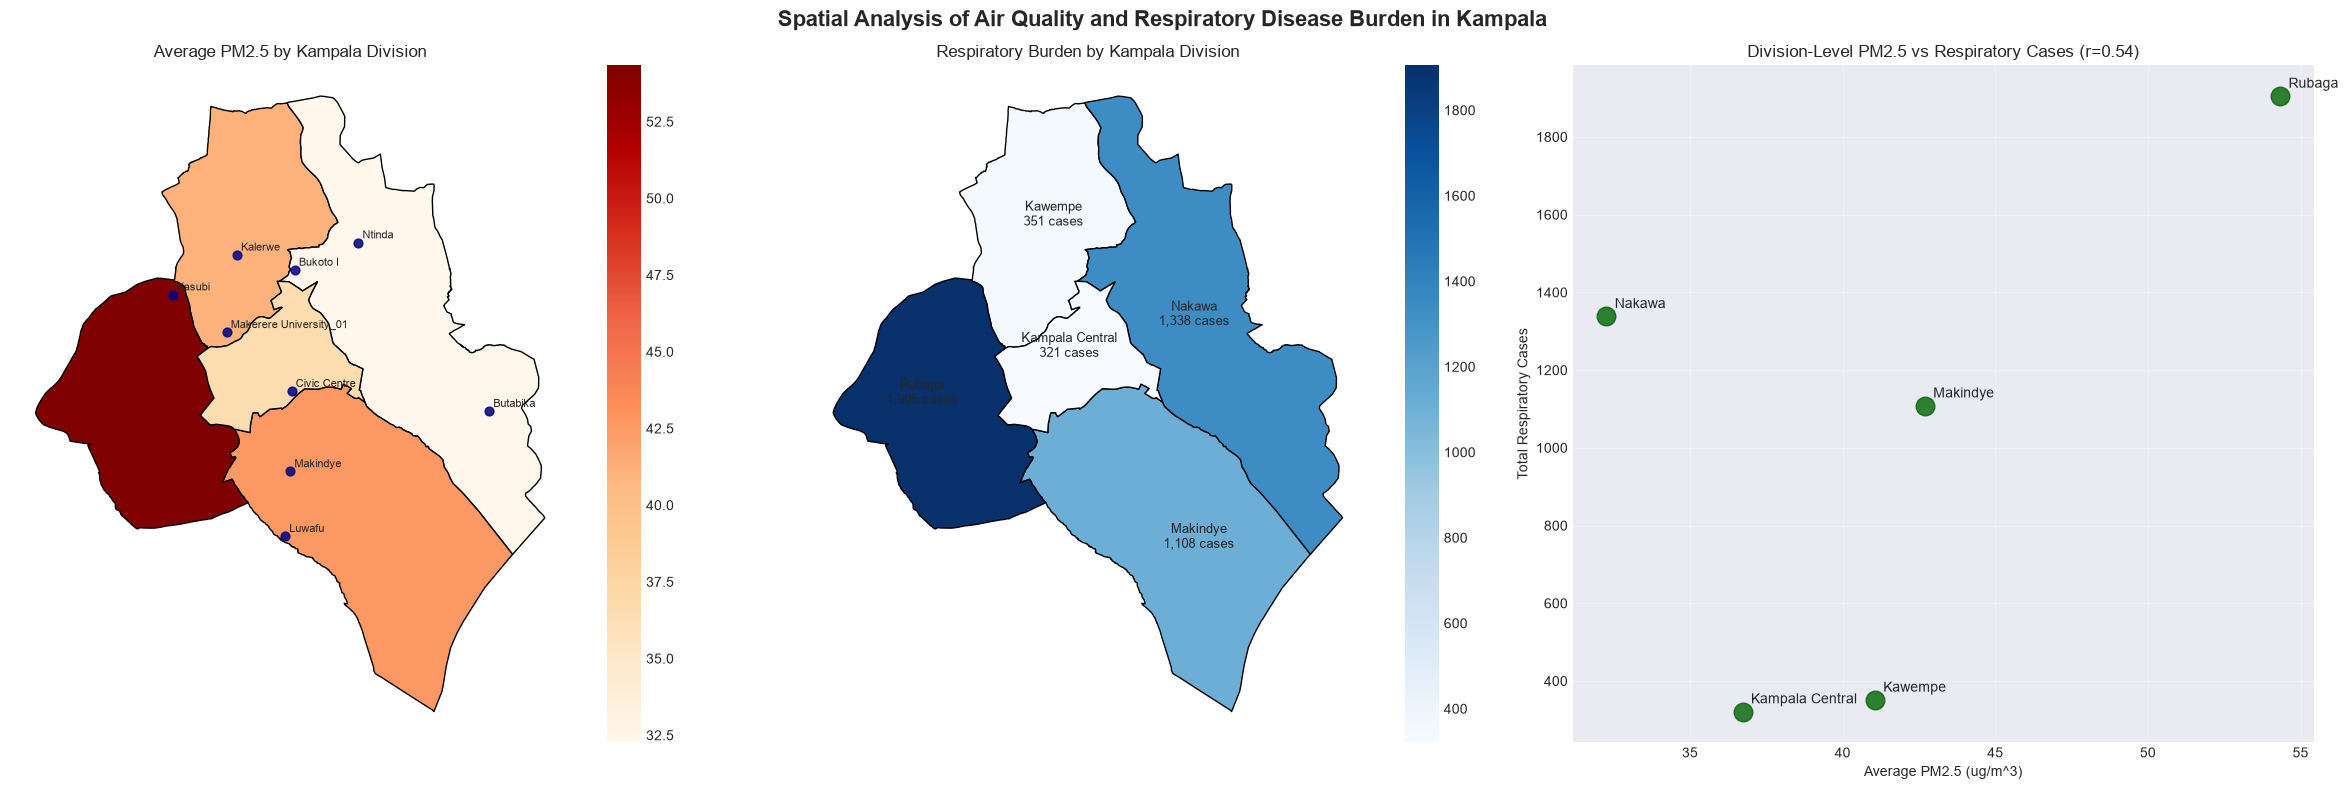

,division,mean_pm25,median_pm25,sensor_sites,monitoring_records,total_respiratory_cases,tb_cases,unique_parishes,dominant_diagnosis,dominant_diagnosis_cases
3,Rubaga,54.334055,47.73570,1,24877,1905,1391,171,Tuberculosis,1391
2,Makindye,42.694804,33.44750,2,53377,1108,979,157,Tuberculosis,979
0,Kawempe,41.058471,31.79715,3,81720,351,284,76,Tuberculosis,284
4,Kampala Central,36.725346,30.46185,1,13214,321,283,71,Tuberculosis,283
1,Nakawa,32.264413,25.41410,2,40520,1338,975,114,Tuberculosis,975


In [43]:
# Division-level spatial analysis combining Kampala polygons, PM2.5 monitors, and health records
try:
    import geopandas as gpd
except ImportError as exc:
    raise ImportError(
        "Spatial analysis requires geopandas in the active notebook environment."
    ) from exc

from pathlib import Path


def standardize_division(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    mapping = {
        'kampala central': 'Kampala Central',
        'central division': 'Kampala Central',
        'central': 'Kampala Central',
        'kawempe': 'Kawempe',
        'kawempe division': 'Kawempe',
        'nakawa': 'Nakawa',
        'nakawa division': 'Nakawa',
        'makindye': 'Makindye',
        'makindye division': 'Makindye',
        'rubaga': 'Rubaga',
        'rubaga division': 'Rubaga',
        'lubaga': 'Rubaga',
        'lubaga division': 'Rubaga',
    }
    return mapping.get(text, str(value).strip().title())


base_path = Path('data')
shapefile_path = base_path / 'Kampala Shapefile' / 'KMA Subcounties.shp'
air_quality_paths = [
    base_path / 'bq-results-20260322-100500-1774173924222.csv',
    base_path / 'bq-results-20260322-100723-1774174052683.csv',
]
health_path = base_path / 'Exploring_the_Association_Between_Air_Quality_and_the_Burden_of_Respiratory_Tract_Infections_in_Greater_Kampala_Uganda_-_all_versions_-_labels_-_2026-06-23-13-15-43.xlsx'
kampala_order = ['Kampala Central', 'Kawempe', 'Makindye', 'Nakawa', 'Rubaga']

kampala_map = gpd.read_file(shapefile_path)
kampala_map['division'] = kampala_map['sname2019'].apply(standardize_division)
kampala_map = (
    kampala_map[kampala_map['division'].isin(kampala_order)]
    .drop_duplicates(subset=['division'])
    .copy()
)

air_frames = []
for csv_path in air_quality_paths:
    frame = pd.read_csv(
        csv_path,
        usecols=[
            'timestamp', 'site_id', 'site_name', 'site_latitude', 'site_longitude',
            'pm2_5_calibrated_value', 'district', 'parish'
        ]
    )
    air_frames.append(frame)

air_spatial = pd.concat(air_frames, ignore_index=True)
air_spatial = air_spatial.drop_duplicates(subset=['timestamp', 'site_id'])
air_spatial['timestamp'] = pd.to_datetime(air_spatial['timestamp'], errors='coerce', utc=True)
air_spatial['division'] = air_spatial['site_name'].str.split(',').str[-1].str.strip().apply(standardize_division)
air_spatial.loc[
    air_spatial['parish'].astype(str).str.contains('makindye division', case=False, na=False),
    'division'
] = 'Makindye'
air_spatial = air_spatial[air_spatial['division'].isin(kampala_order)].copy()

division_pm25 = (
    air_spatial.groupby('division')
    .agg(
        mean_pm25=('pm2_5_calibrated_value', 'mean'),
        median_pm25=('pm2_5_calibrated_value', 'median'),
        sensor_sites=('site_id', 'nunique'),
        monitoring_records=('pm2_5_calibrated_value', 'size')
    )
    .reset_index()
)

sensor_points = (
    air_spatial.groupby(['site_id', 'site_name', 'division'], as_index=False)
    .agg(
        site_latitude=('site_latitude', 'mean'),
        site_longitude=('site_longitude', 'mean'),
        mean_pm25=('pm2_5_calibrated_value', 'mean')
    )
)
sensor_gdf = gpd.GeoDataFrame(
    sensor_points,
    geometry=gpd.points_from_xy(sensor_points['site_longitude'], sensor_points['site_latitude']),
    crs='EPSG:4326'
)

health_spatial = pd.read_excel(health_path)
health_spatial['visit_date'] = pd.to_datetime(health_spatial['4. Date of hospital visit:'], errors='coerce')
health_spatial['division'] = health_spatial['10. Division (Kampala)'].apply(standardize_division)
health_spatial['diagnosis'] = health_spatial['3. Patient Diagnosis'].fillna('Unknown')
health_spatial = health_spatial[health_spatial['division'].isin(kampala_order)].copy()

division_health = (
    health_spatial.groupby('division')
    .agg(
        total_respiratory_cases=('diagnosis', 'size'),
        tb_cases=('diagnosis', lambda x: (x == 'Tuberculosis').sum()),
        unique_parishes=('12. Parish name:', lambda x: x.dropna().nunique())
    )
    .reset_index()
)

dominant_diagnosis = (
    health_spatial.groupby(['division', 'diagnosis'])
    .size()
    .reset_index(name='cases')
    .sort_values(['division', 'cases'], ascending=[True, False])
    .drop_duplicates(subset=['division'])
    .rename(columns={'diagnosis': 'dominant_diagnosis', 'cases': 'dominant_diagnosis_cases'})
)

spatial_summary = (
    kampala_map[['division', 'geometry']]
    .merge(division_pm25, on='division', how='left')
    .merge(division_health, on='division', how='left')
    .merge(dominant_diagnosis, on='division', how='left')
)

for col in ['mean_pm25', 'median_pm25', 'total_respiratory_cases', 'tb_cases', 'unique_parishes']:
    spatial_summary[col] = spatial_summary[col].fillna(0)

label_points = spatial_summary.geometry.representative_point()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

spatial_summary.plot(
    column='mean_pm25',
    cmap='OrRd',
    linewidth=1,
    edgecolor='black',
    legend=True,
    ax=axes[0],
    missing_kwds={'color': '#f0f0f0', 'label': 'No PM2.5 data'}
)
sensor_gdf.plot(ax=axes[0], color='navy', markersize=40, alpha=0.85)
for _, row in sensor_points.iterrows():
    axes[0].annotate(
        row['site_name'].split(',')[0].strip(),
        (row['site_longitude'], row['site_latitude']),
        xytext=(3, 3),
        textcoords='offset points',
        fontsize=8
    )
axes[0].set_title('Average PM2.5 by Kampala Division')
axes[0].set_axis_off()

spatial_summary.plot(
    column='total_respiratory_cases',
    cmap='Blues',
    linewidth=1,
    edgecolor='black',
    legend=True,
    ax=axes[1],
    missing_kwds={'color': '#f0f0f0', 'label': 'No health data'}
)
for point, division, total_cases in zip(label_points, spatial_summary['division'], spatial_summary['total_respiratory_cases']):
    axes[1].annotate(
        f"{division}\n{int(total_cases):,} cases",
        (point.x, point.y),
        ha='center',
        fontsize=9
    )
axes[1].set_title('Respiratory Burden by Kampala Division')
axes[1].set_axis_off()

axes[2].scatter(
    spatial_summary['mean_pm25'],
    spatial_summary['total_respiratory_cases'],
    s=180,
    color='darkgreen',
    alpha=0.8
)
for _, row in spatial_summary.dropna(subset=['mean_pm25', 'total_respiratory_cases']).iterrows():
    axes[2].annotate(
        row['division'],
        (row['mean_pm25'], row['total_respiratory_cases']),
        xytext=(6, 6),
        textcoords='offset points'
    )
if spatial_summary['mean_pm25'].notna().sum() >= 2 and spatial_summary['total_respiratory_cases'].notna().sum() >= 2:
    spatial_corr = spatial_summary[['mean_pm25', 'total_respiratory_cases']].dropna()
    corr_value = spatial_corr['mean_pm25'].corr(spatial_corr['total_respiratory_cases'])
    axes[2].set_title(f'Division-Level PM2.5 vs Respiratory Cases (r={corr_value:.2f})')
else:
    axes[2].set_title('Division-Level PM2.5 vs Respiratory Cases')
axes[2].set_xlabel('Average PM2.5 (ug/m^3)')
axes[2].set_ylabel('Total Respiratory Cases')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Spatial Analysis of Air Quality and Respiratory Disease Burden in Kampala', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

spatial_summary_table = spatial_summary[
    [
        'division', 'mean_pm25', 'median_pm25', 'sensor_sites', 'monitoring_records',
        'total_respiratory_cases', 'tb_cases', 'unique_parishes',
        'dominant_diagnosis', 'dominant_diagnosis_cases'
    ]
].sort_values('mean_pm25', ascending=False)
spatial_summary_table


## Step 4: Time Series Modeling


### 4.1 Interrupted Time Series


#### 4.1.1 ITS Preparation and Counterfactual Estimation


In [44]:
# --- 1. Data Preprocessing ---
data_itsa = processed_data.copy()
date_source = processed_data['date'] if 'date' in processed_data.columns else processed_data['ds']
data_itsa['date'] = pd.to_datetime(date_source, errors='coerce', dayfirst=True)
data_itsa = data_itsa.dropna(subset=['date']).sort_values('date').set_index('date')


In [45]:
# --- 2. Handle Missing Data ---
its_numeric_cols = [
    col for col in ['TB', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in data_itsa.columns
]
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].apply(pd.to_numeric, errors='coerce')
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].interpolate(limit_direction='both').ffill().bfill()

print(f"Prepared ITS dataset with {len(data_itsa)} rows and {len(its_numeric_cols)} core numeric features.")


Prepared ITS dataset with 248 rows and 6 core numeric features.


In [46]:
# --- 3. Define the Intervention Point ---
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which corresponds to the date: {intervention_date.date()}")



The dataset has 248 data points.
The intervention is set at index 124, which corresponds to the date: 2022-05-29


In [47]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values


In [48]:
# --- 5. LSTM Modeling for predicted_tb ---

feature_cols = [
    'TB', 'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
    'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
    'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
    'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
    'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
    'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
    'time_since_intervention'
]

sequence_length = 8
lstm_df = data_itsa[feature_cols].copy().fillna(0)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(lstm_df)
scaled_target = target_scaler.fit_transform(data_itsa[['TB']])

def build_sequences(features, target, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i-seq_len:i])
        y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

X_all, y_all = build_sequences(scaled_features, scaled_target, sequence_length)
train_end = max(sequence_length + 1, intervention_point)
X_train, y_train = X_all[:train_end-sequence_length], y_all[:train_end-sequence_length]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, X_all.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stopping]
)

pred_scaled = lstm_model.predict(X_all, verbose=0)
pred_tb = target_scaler.inverse_transform(pred_scaled).flatten()

data_itsa['predicted_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('predicted_tb')] = pred_tb

counterfactual_features = lstm_df.copy()
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'intervention'] = 0
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'time_since_intervention'] = 0
scaled_counterfactual = feature_scaler.transform(counterfactual_features.fillna(0))
X_counterfactual, _ = build_sequences(scaled_counterfactual, scaled_target, sequence_length)
counter_scaled = lstm_model.predict(X_counterfactual, verbose=0)
counter_tb = target_scaler.inverse_transform(counter_scaled).flatten()

data_itsa['counterfactual_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('counterfactual_tb')] = counter_tb

actual_for_metrics = data_itsa['TB'].iloc[sequence_length:]
pred_for_metrics = data_itsa['predicted_tb'].iloc[sequence_length:]
rmse = np.sqrt(mean_squared_error(actual_for_metrics, pred_for_metrics))
mae = mean_absolute_error(actual_for_metrics, pred_for_metrics)

print("\n--- LSTM Model Summary ---")
print(f"Features used: {len(feature_cols)}")
print(f"Sequence length: {sequence_length} weeks")
print(f"Training windows: {len(X_train)}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")



--- LSTM Model Summary ---
Features used: 48
Sequence length: 8 weeks
Training windows: 116
Best validation loss: 0.010503
RMSE: 200.69
MAE: 151.76


### 4.2 Overall ITS Analysis of TB Cases


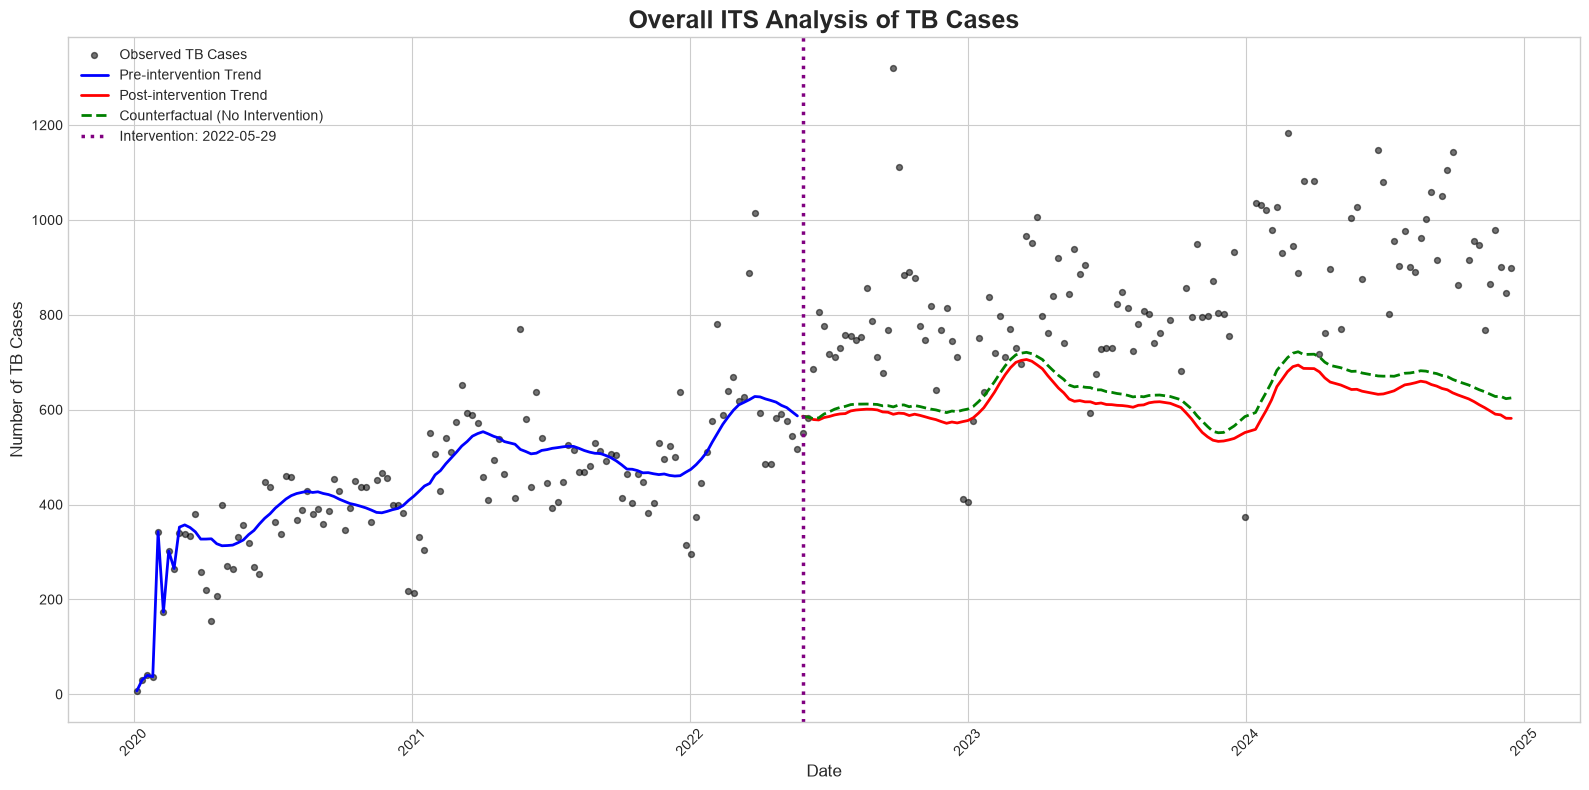

In [49]:
data_itsa.index = pd.to_datetime(data_itsa.index, errors='coerce')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

ax.scatter(data_itsa.index, data_itsa['TB'], color='black', alpha=0.55, label='Observed TB Cases', s=18)

pre_data = data_itsa[data_itsa['intervention'] == 0]
post_data = data_itsa[data_itsa['intervention'] == 1]
ax.plot(pre_data.index, pre_data['predicted_tb'], color='blue', linewidth=2, label='Pre-intervention Trend')
ax.plot(post_data.index, post_data['predicted_tb'], color='red', linewidth=2, label='Post-intervention Trend')
ax.plot(post_data.index, post_data['counterfactual_tb'], color='green', linestyle='--', linewidth=2, label='Counterfactual (No Intervention)')

ax.axvline(x=intervention_date, color='purple', linestyle=':', linewidth=2.5, label=f'Intervention: {intervention_date.date()}')

ax.set_title('Overall ITS Analysis of TB Cases', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of TB Cases', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4.3 TensorFlow Forecast Preparation


In [50]:
data_project = processed_data.copy()
if 'date' in data_project.columns:
    data_project['ds'] = pd.to_datetime(data_project['date'], errors='coerce', dayfirst=True)
else:
    data_project['ds'] = pd.to_datetime(data_project['ds'], errors='coerce', dayfirst=True)

disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths'] if col in data_project.columns]
data_project = data_project.sort_values('ds').reset_index(drop=True)

if 'county' not in data_project.columns:
    data_project['county'] = 'Kampala'
data_project['year_month'] = data_project['ds'].dt.to_period('M').astype(str)

if 'month' not in data_project.columns:
    data_project['month'] = data_project['ds'].dt.month
if 'week_of_year' not in data_project.columns:
    data_project['week_of_year'] = data_project['ds'].dt.isocalendar().week.astype(int)
if 'quarter' not in data_project.columns:
    data_project['quarter'] = data_project['ds'].dt.quarter
if 'day_of_year' not in data_project.columns:
    data_project['day_of_year'] = data_project['ds'].dt.dayofyear
if 'is_weekend' not in data_project.columns:
    data_project['is_weekend'] = data_project['ds'].dt.dayofweek.isin([5, 6]).astype(int)

if 'time' not in data_project.columns:
    data_project['time'] = np.arange(1, len(data_project) + 1)

if 'intervention' not in data_project.columns or 'time_since_intervention' not in data_project.columns:
    intervention_point = len(data_project) // 2
    intervention_date = data_project.loc[intervention_point, 'ds']
    data_project['intervention'] = (data_project['ds'] >= intervention_date).astype(int)
    data_project['time_since_intervention'] = np.where(
        data_project['intervention'] == 1,
        np.arange(len(data_project)) - intervention_point,
        0
    )
else:
    intervention_date = data_project.loc[data_project['intervention'].eq(1), 'ds'].min()

print(f"Using {len(disease_cols)} diseases for downstream TensorFlow modeling:")
print(disease_cols)
print(f"Intervention date reference: {pd.to_datetime(intervention_date).date()}")


Using 7 diseases for downstream TensorFlow modeling:
['TB', 'ILI', 'ILD_deaths', 'pneumonia_u5', 'pneumonia_u5_deaths', 'SARI', 'SARI_deaths']
Intervention date reference: 2022-05-29


### 4.4 TensorFlow Fusion Forecast Helpers


In [51]:
sequence_length = 8

base_sequence_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'avgtemp_sat', 'humidity_sat', 'temp_humidity_interaction',
    'temp_sat_gap', 'humidity_sat_gap', 'precip_rolling_4',
    'windspeed_rolling_4', 'pm25_temp_ratio', 'pm25_humidity_ratio',
    'pm25_trailing_ma_7', 'tb_trailing_ma_7', 'pm25_trailing_ma_14', 'tb_trailing_ma_14',
    'pm25_trailing_ma_30', 'tb_trailing_ma_30', 'pm25_leading_ma_7', 'tb_leading_ma_7',
    'pm25_leading_ma_14', 'tb_leading_ma_14', 'pm25_leading_ma_30', 'tb_leading_ma_30',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]
base_dense_candidates = [
    'time', 'intervention', 'time_since_intervention', 'month',
    'week_of_year', 'quarter', 'day_of_year', 'is_weekend',
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month'
]

benchmark_feature_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month'
]


def build_target_features(frame, disease):
    target_frame = frame.copy()
    lag_cols = []
    ma_cols = []
    for lag in [1, 2, 3, 4]:
        col = f'{disease}_lag_{lag}'
        target_frame[col] = target_frame[disease].shift(lag)
        lag_cols.append(col)
    for window in [4, 8]:
        trailing_col = f'{disease}_trailing_ma_{window}'
        target_frame[trailing_col] = target_frame[disease].rolling(window=window, min_periods=1).mean()
        ma_cols.append(trailing_col)
        leading_col = f'{disease}_leading_ma_{window}'
        target_frame[leading_col] = target_frame[disease].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
        ma_cols.append(leading_col)
    diff_col = f'{disease}_diff_1'
    pct_col = f'{disease}_pct_change_1'
    target_frame[diff_col] = target_frame[disease].diff()
    target_frame[pct_col] = target_frame[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    return target_frame, lag_cols, ma_cols, diff_col, pct_col


def create_fusion_arrays(frame, sequence_cols, dense_cols, target_col, seq_len):
    X_seq, X_dense, y, dates = [], [], [], []
    for idx in range(seq_len, len(frame)):
        X_seq.append(frame.loc[idx - seq_len:idx - 1, sequence_cols].to_numpy(dtype=float))
        X_dense.append(frame.loc[idx, dense_cols].to_numpy(dtype=float))
        y.append(float(frame.loc[idx, target_col]))
        dates.append(frame.loc[idx, 'ds'])
    return np.asarray(X_seq), np.asarray(X_dense), np.asarray(y), pd.to_datetime(dates)


def build_fusion_model(seq_shape, dense_dim):
    sequence_input = Input(shape=seq_shape, name='sequence_input')
    sequence_branch = LSTM(32, dropout=0.1, name='sequence_lstm')(sequence_input)
    sequence_branch = Dense(16, activation='relu', name='sequence_dense')(sequence_branch)

    dense_input = Input(shape=(dense_dim,), name='dense_input')
    dense_branch = Dense(16, activation='relu', name='dense_dense')(dense_input)
    dense_branch = Dropout(0.1, name='dense_dropout')(dense_branch)

    fused = Concatenate(name='fusion_concat')([sequence_branch, dense_branch])
    fused = Dense(16, activation='relu', name='fusion_dense')(fused)
    output = Dense(1, name='prediction')(fused)

    model = Model(inputs=[sequence_input, dense_input], outputs=output, name='fusion_lstm_regressor')
    model.compile(optimizer='adam', loss='mse')
    return model


def train_disease_fusion_model(frame, disease, seq_len=8, test_fraction=0.2):
    target_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)

    sequence_cols = [col for col in base_sequence_candidates if col in target_frame.columns]
    sequence_cols += [col for col in lag_cols + ma_cols if col in target_frame.columns]

    dense_cols = [col for col in base_dense_candidates if col in target_frame.columns]
    dense_cols += [col for col in [diff_col, pct_col] if col in target_frame.columns]

    needed_cols = ['ds', disease] + sequence_cols + dense_cols
    model_frame = target_frame[needed_cols].copy().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(model_frame) <= seq_len + 10:
        raise ValueError(f'Not enough usable rows for {disease} after feature engineering.')

    X_seq_raw, X_dense_raw, y_raw, dates = create_fusion_arrays(
        model_frame,
        sequence_cols=sequence_cols,
        dense_cols=dense_cols,
        target_col=disease,
        seq_len=seq_len
    )

    total_samples = len(y_raw)
    split_idx = max(8, int(total_samples * (1 - test_fraction)))
    split_idx = min(split_idx, total_samples - 2)
    if split_idx <= 1:
        raise ValueError(f'Not enough train/test samples for {disease}.')

    X_seq_train_raw = X_seq_raw[:split_idx]
    X_seq_test_raw = X_seq_raw[split_idx:]
    X_dense_train_raw = X_dense_raw[:split_idx]
    X_dense_test_raw = X_dense_raw[split_idx:]
    y_train_raw = y_raw[:split_idx]
    y_test_raw = y_raw[split_idx:]

    sequence_scaler = MinMaxScaler()
    dense_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    sequence_scaler.fit(X_seq_train_raw.reshape(-1, X_seq_train_raw.shape[-1]))
    dense_scaler.fit(X_dense_train_raw)
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    def scale_sequence(values):
        scaled = sequence_scaler.transform(values.reshape(-1, values.shape[-1]))
        return scaled.reshape(values.shape)

    X_seq_train = scale_sequence(X_seq_train_raw)
    X_seq_test = scale_sequence(X_seq_test_raw)
    X_dense_train = dense_scaler.transform(X_dense_train_raw)
    X_dense_test = dense_scaler.transform(X_dense_test_raw)
    y_train = target_scaler.transform(y_train_raw.reshape(-1, 1))

    model = build_fusion_model((seq_len, X_seq_train.shape[-1]), X_dense_train.shape[-1])
    callbacks = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
    history = model.fit(
        [X_seq_train, X_dense_train],
        y_train,
        epochs=40,
        batch_size=min(16, max(4, len(X_seq_train))),
        validation_split=0.2 if len(X_seq_train) >= 12 else 0.0,
        verbose=0,
        callbacks=callbacks if len(X_seq_train) >= 12 else []
    )

    y_train_pred = target_scaler.inverse_transform(
        model.predict([X_seq_train, X_dense_train], verbose=0)
    ).flatten()
    y_test_pred = target_scaler.inverse_transform(
        model.predict([X_seq_test, X_dense_test], verbose=0)
    ).flatten()

    train_residual_std = float(np.std(y_train_raw - y_train_pred)) if len(y_train_raw) > 1 else 0.0
    all_predictions = np.concatenate([y_train_pred, y_test_pred])

    metrics = {
        'Disease': disease,
        'Model': 'TensorFlow Fusion LSTM + Dense',
        'MAE': mean_absolute_error(y_test_raw, y_test_pred),
        'RMSE': mean_squared_error(y_test_raw, y_test_pred) ** 0.5,
        'R²': r2_score(y_test_raw, y_test_pred) if len(y_test_raw) > 1 else np.nan,
        'Train Samples': int(len(y_train_raw)),
        'Test Samples': int(len(y_test_raw))
    }

    prediction_frame = pd.DataFrame({
        'ds': dates,
        'actual': y_raw,
        'predicted': all_predictions,
        'lower': all_predictions - 1.96 * train_residual_std,
        'upper': all_predictions + 1.96 * train_residual_std,
        'dataset_split': ['Train' if idx < split_idx else 'Test' for idx in range(total_samples)]
    })

    return {
        'metrics': metrics,
        'history': history.history,
        'prediction_frame': prediction_frame,
        'sequence_cols': sequence_cols,
        'dense_cols': dense_cols
    }


def run_benchmark_models(frame, disease):
    benchmark_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)
    benchmark_features = [col for col in benchmark_feature_candidates if col in benchmark_frame.columns]
    benchmark_features += [col for col in lag_cols + ma_cols + [diff_col, pct_col] if col in benchmark_frame.columns]

    benchmark_frame = benchmark_frame.copy().replace([np.inf, -np.inf], np.nan)
    benchmark_frame['county'] = benchmark_frame.get('county', 'Kampala')
    benchmark_frame['year_month'] = benchmark_frame['ds'].dt.to_period('M').astype(str)

    ts_modeler = TimeSeriesModeler(benchmark_frame, target_column=disease)
    X_ts, y_ts = ts_modeler.prepare_time_series_data(
        window_size=sequence_length,
        features=benchmark_features,
        target_type='binary'
    )

    if len(X_ts) == 0 or len(y_ts) == 0:
        raise ValueError(f'No usable benchmark windows for {disease}.')

    benchmark_results = ts_modeler.train_models(
        X_ts,
        y_ts,
        models_to_train=['random_forest', 'gradient_boosting', 'svm'],
        cv_splits=3
    )

    if not benchmark_results:
        raise ValueError(f'No benchmark models trained for {disease}.')

    best_model_name = max(benchmark_results, key=lambda name: benchmark_results[name]['avg_f1'])
    best_metrics = benchmark_results[best_model_name]
    return {
        'Disease': disease,
        'Best Benchmark Model': best_model_name,
        'Benchmark Accuracy': best_metrics.get('avg_accuracy', np.nan),
        'Benchmark F1': best_metrics.get('avg_f1', np.nan),
        'Benchmark Precision': best_metrics.get('avg_precision', np.nan),
        'Benchmark Recall': best_metrics.get('avg_recall', np.nan)
    }


### 4.5 TensorFlow Disease Forecasts



=== Training TensorFlow fusion model for TB ===
Train samples: 188, Test samples: 48, MAE: 219.242, RMSE: 279.782, R²: -3.182


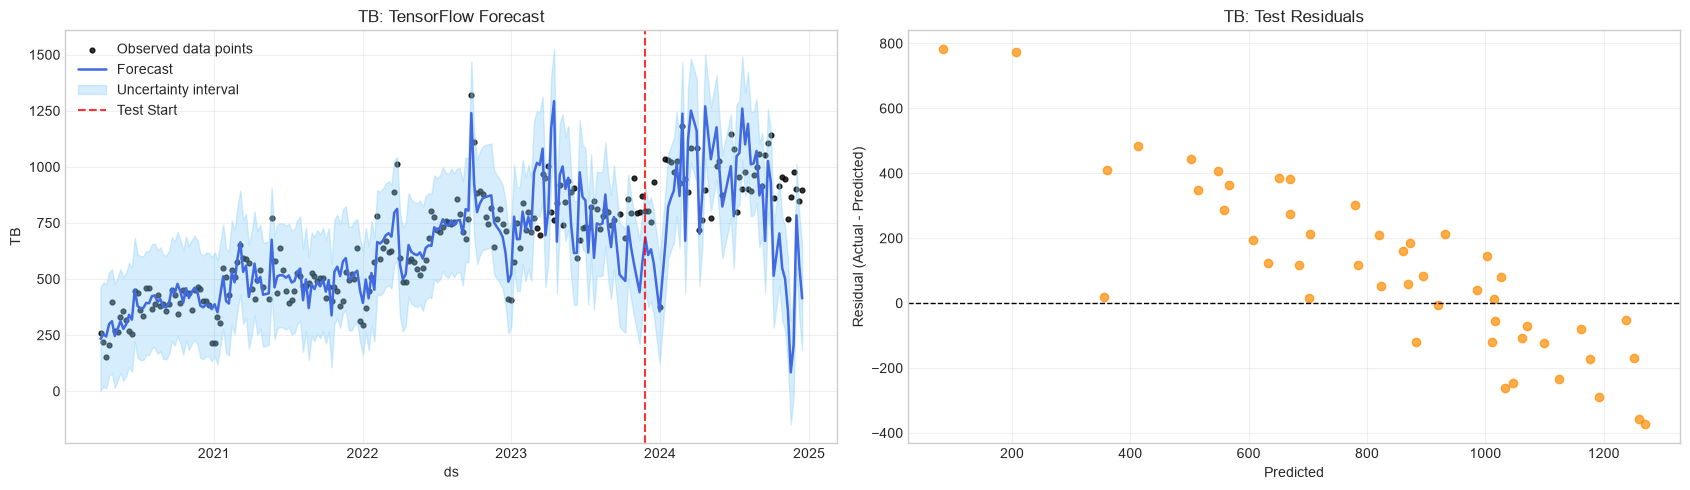

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: TB
INFO:time_series_modeler:Prepared 240 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for TB ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.914)



=== Training TensorFlow fusion model for ILI ===
Train samples: 185, Test samples: 47, MAE: 1333.245, RMSE: 1559.969, R²: -2.122


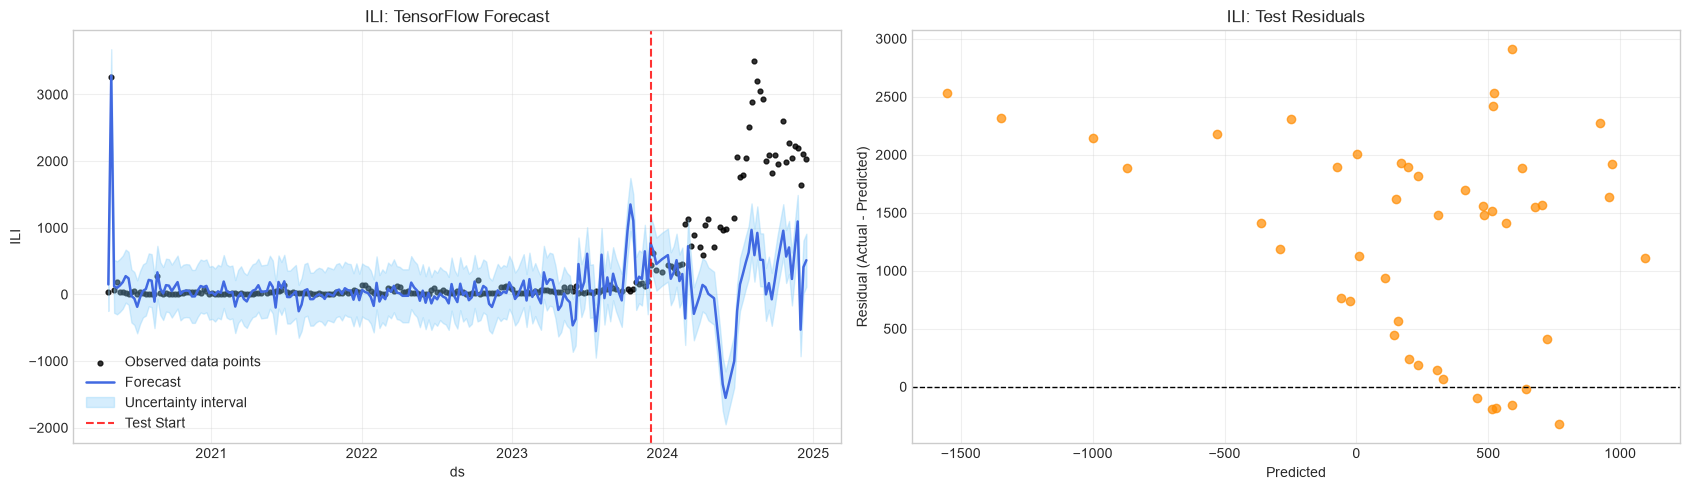

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: ILI
INFO:time_series_modeler:Prepared 240 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for ILI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.728)
INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: ILD_deaths
INFO:time_series_modeler:Prepared 56 samples with 304 features
INFO:time_series_modeler:Training random_forest...



=== Training TensorFlow fusion model for ILD_deaths ===
Skipping TensorFlow model for ILD_deaths: Not enough usable rows for ILD_deaths after feature engineering.
=== Benchmarking classical time-series models for ILD_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.676)



=== Training TensorFlow fusion model for pneumonia_u5 ===
Train samples: 188, Test samples: 48, MAE: 170.498, RMSE: 194.846, R²: -27.605


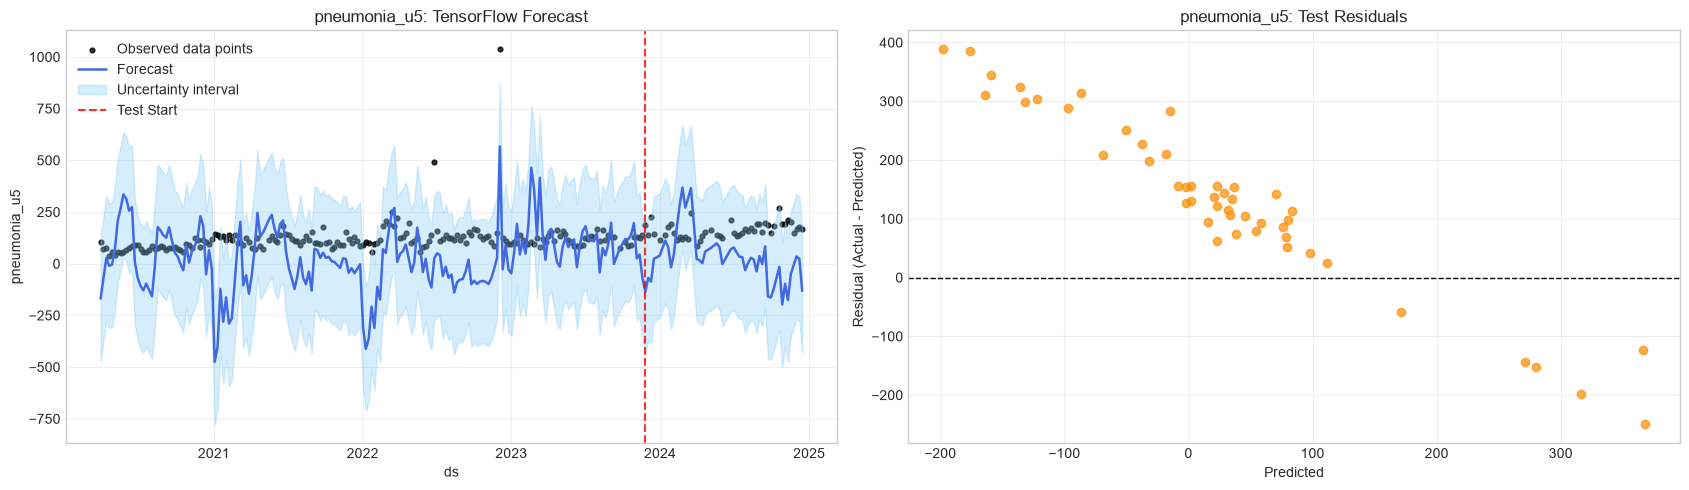

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: pneumonia_u5
INFO:time_series_modeler:Prepared 240 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia_u5 ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.695)



=== Training TensorFlow fusion model for pneumonia_u5_deaths ===
Train samples: 60, Test samples: 15, MAE: 4.060, RMSE: 4.779, R²: -2.328


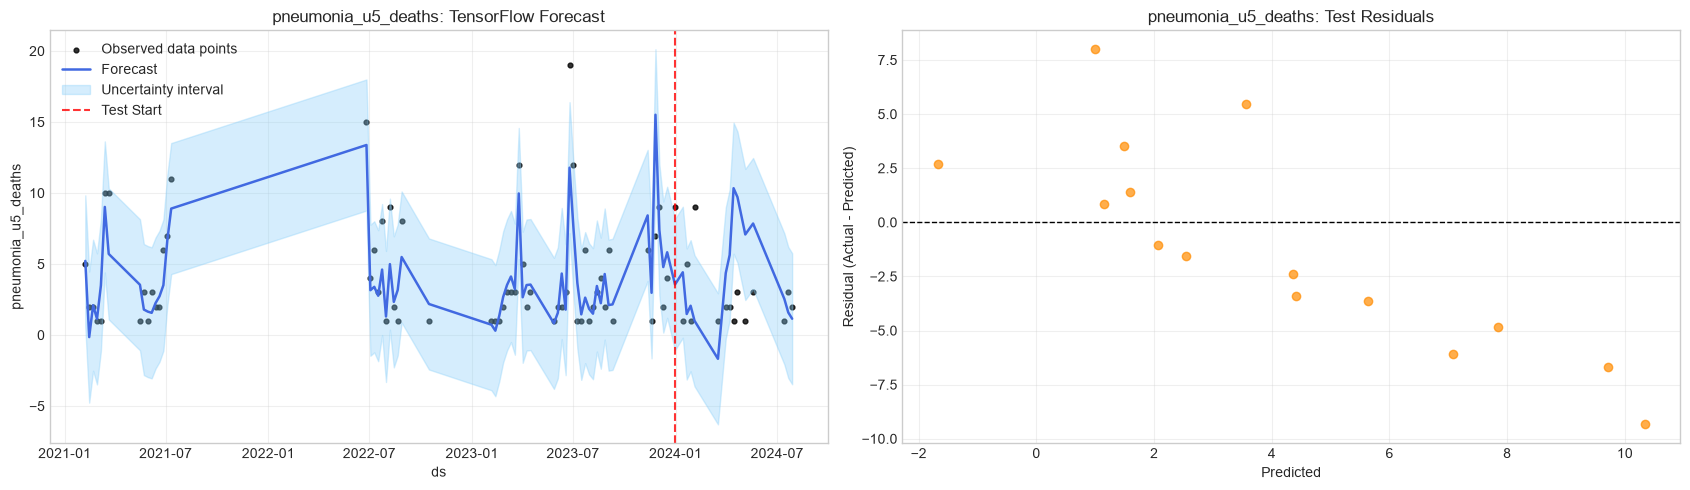

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: pneumonia_u5_deaths
INFO:time_series_modeler:Prepared 189 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia_u5_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.533)



=== Training TensorFlow fusion model for SARI ===
Train samples: 188, Test samples: 48, MAE: 522.790, RMSE: 594.244, R²: -16.429


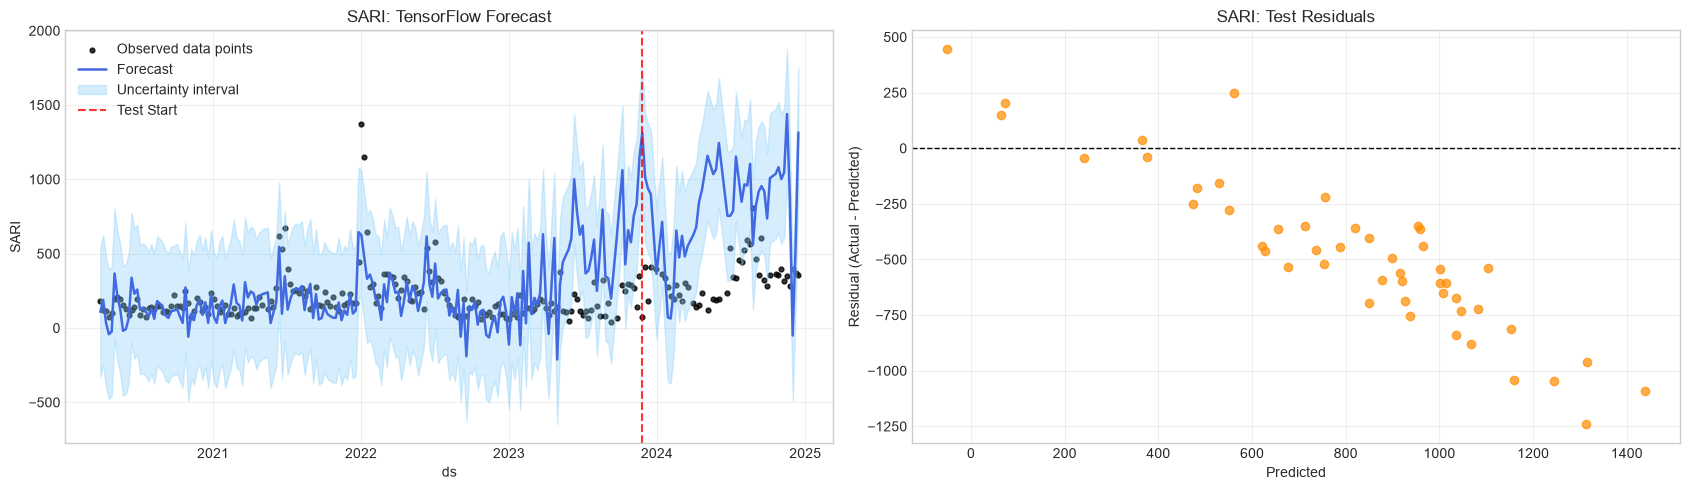

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: SARI
INFO:time_series_modeler:Prepared 240 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.700)



=== Training TensorFlow fusion model for SARI_deaths ===
Train samples: 12, Test samples: 3, MAE: 2.991, RMSE: 3.971, R²: -1.838


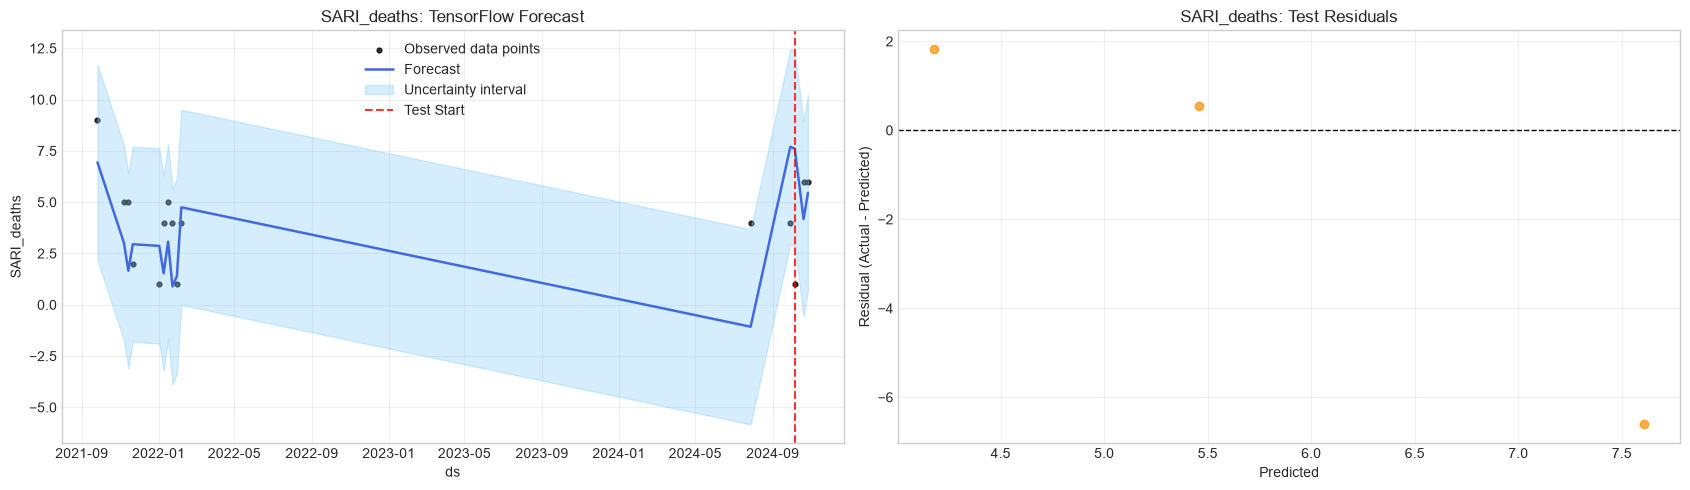

INFO:time_series_modeler:TimeSeriesModeler initialized with 248 records, target: SARI_deaths
INFO:time_series_modeler:Prepared 111 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.680)


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,2.991209,3.970636,-1.837871,12,3
1,pneumonia_u5_deaths,TensorFlow Fusion LSTM + Dense,4.060284,4.778707,-2.327792,60,15
2,pneumonia_u5,TensorFlow Fusion LSTM + Dense,170.498089,194.845781,-27.605147,188,48
3,TB,TensorFlow Fusion LSTM + Dense,219.241772,279.781530,-3.182218,188,48
4,SARI,TensorFlow Fusion LSTM + Dense,522.790254,594.244216,-16.429460,188,48
5,ILI,TensorFlow Fusion LSTM + Dense,1333.245248,1559.969371,-2.122445,185,47


In [52]:
models_performance_records = []
benchmark_records = []
disease_forecasts = {}

for disease in disease_cols:
    print(f"\n=== Training TensorFlow fusion model for {disease} ===")
    try:
        result = train_disease_fusion_model(data_project, disease, seq_len=sequence_length)
        disease_forecasts[disease] = result['prediction_frame']
        models_performance_records.append(result['metrics'])

        plot_df = result['prediction_frame']
        print(
            f"Train samples: {result['metrics']['Train Samples']}, "
            f"Test samples: {result['metrics']['Test Samples']}, "
            f"MAE: {result['metrics']['MAE']:.3f}, "
            f"RMSE: {result['metrics']['RMSE']:.3f}, "
            f"R²: {result['metrics']['R²']:.3f}"
        )

        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        axes[0].scatter(plot_df['ds'], plot_df['actual'], color='black', s=12, alpha=0.8, label='Observed data points')
        axes[0].plot(plot_df['ds'], plot_df['predicted'], color='royalblue', linewidth=1.8, label='Forecast')
        axes[0].fill_between(
            plot_df['ds'],
            plot_df['lower'],
            plot_df['upper'],
            color='lightskyblue',
            alpha=0.35,
            label='Uncertainty interval'
        )
        test_dates = plot_df.loc[plot_df['dataset_split'] == 'Test', 'ds']
        if not test_dates.empty:
            axes[0].axvline(test_dates.iloc[0], color='red', linestyle='--', alpha=0.8, label='Test Start')
        axes[0].set_title(f'{disease}: TensorFlow Forecast')
        axes[0].set_xlabel('ds')
        axes[0].set_ylabel(disease)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        test_df = plot_df[plot_df['dataset_split'] == 'Test'].copy()
        if len(test_df) >= 2:
            residuals = test_df['actual'] - test_df['predicted']
            axes[1].scatter(test_df['predicted'], residuals, alpha=0.7, color='darkorange')
            axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
            axes[1].set_title(f'{disease}: Test Residuals')
            axes[1].set_xlabel('Predicted')
            axes[1].set_ylabel('Residual (Actual - Predicted)')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].axis('off')
            axes[1].text(0.5, 0.5, 'Not enough test points for residual plot', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Skipping TensorFlow model for {disease}: {exc}")

    print(f"=== Benchmarking classical time-series models for {disease} ===")
    try:
        benchmark_records.append(run_benchmark_models(data_project, disease))
    except Exception as exc:
        print(f"Skipping benchmark models for {disease}: {exc}")

models_performance = pd.DataFrame(models_performance_records)
if not models_performance.empty:
    models_performance = models_performance.sort_values('RMSE').reset_index(drop=True)

benchmark_performance = pd.DataFrame(benchmark_records)
if not benchmark_performance.empty:
    benchmark_performance = benchmark_performance.sort_values('Benchmark F1', ascending=False).reset_index(drop=True)

models_performance


### 4.6 Model Comparison


In [53]:
print('--- TensorFlow Fusion Model Summary ---')
if not models_performance.empty:
    print(models_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    best_disease_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"\nBest-performing disease by RMSE: {best_disease_row['Disease']} "
        f"(RMSE={best_disease_row['RMSE']:.3f}, MAE={best_disease_row['MAE']:.3f}, R²={best_disease_row['R²']:.3f})"
    )
else:
    print('No TensorFlow disease models completed successfully.')

print('\n--- Classical Time-Series Benchmark Summary ---')
if not benchmark_performance.empty:
    print(benchmark_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
else:
    print('No benchmark models completed successfully.')

if not models_performance.empty and not benchmark_performance.empty:
    model_comparison = models_performance.merge(benchmark_performance, on='Disease', how='left')
    print('\n--- Per-Disease Model Comparison ---')
    print(
        model_comparison[
            [
                'Disease', 'Model', 'MAE', 'RMSE', 'R²',
                'Best Benchmark Model', 'Benchmark Accuracy', 'Benchmark F1'
            ]
        ].to_string(index=False, float_format=lambda x: f'{x:.3f}')
    )
else:
    model_comparison = pd.DataFrame()

model_comparison


--- TensorFlow Fusion Model Summary ---
            Disease                          Model      MAE     RMSE      R²  Train Samples  Test Samples
        SARI_deaths TensorFlow Fusion LSTM + Dense    2.991    3.971  -1.838             12             3
pneumonia_u5_deaths TensorFlow Fusion LSTM + Dense    4.060    4.779  -2.328             60            15
       pneumonia_u5 TensorFlow Fusion LSTM + Dense  170.498  194.846 -27.605            188            48
                 TB TensorFlow Fusion LSTM + Dense  219.242  279.782  -3.182            188            48
               SARI TensorFlow Fusion LSTM + Dense  522.790  594.244 -16.429            188            48
                ILI TensorFlow Fusion LSTM + Dense 1333.245 1559.969  -2.122            185            47

Best-performing disease by RMSE: SARI_deaths (RMSE=3.971, MAE=2.991, R²=-1.838)

--- Classical Time-Series Benchmark Summary ---
            Disease Best Benchmark Model  Benchmark Accuracy  Benchmark F1  Benchmark Pr

,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples,Best Benchmark Model,Benchmark Accuracy,Benchmark F1,Benchmark Precision,Benchmark Recall
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,2.991209,3.970636,-1.837871,12,3,gradient_boosting,0.691358,0.680236,0.693781,0.691358
1,pneumonia_u5_deaths,TensorFlow Fusion LSTM + Dense,4.060284,4.778707,-2.327792,60,15,gradient_boosting,0.539007,0.532750,0.552652,0.539007
2,pneumonia_u5,TensorFlow Fusion LSTM + Dense,170.498089,194.845781,-27.605147,188,48,gradient_boosting,0.683333,0.694822,0.739489,0.683333
3,TB,TensorFlow Fusion LSTM + Dense,219.241772,279.781530,-3.182218,188,48,random_forest,0.938889,0.914210,0.895297,0.938889
4,SARI,TensorFlow Fusion LSTM + Dense,522.790254,594.244216,-16.429460,188,48,gradient_boosting,0.688889,0.699532,0.745563,0.688889
5,ILI,TensorFlow Fusion LSTM + Dense,1333.245248,1559.969371,-2.122445,185,47,random_forest,0.738889,0.728338,0.750056,0.738889


## Step 5: Intervention Simulation


In [54]:
# Get baseline metrics
baseline = {
    'baseline_pm25': processed_data['pm2_5'].dropna().mean(),
    'baseline_tb': processed_data['TB'].dropna().mean(),
    'total_tb_cases': processed_data['TB'].dropna().sum()
}

print('Baseline Metrics:')
print(f"- Average PM2.5: {baseline['baseline_pm25']:.2f} μg/m³")
print(f"- Average TB cases: {baseline['baseline_tb']:.2f}")
print(f"- Total TB cases: {baseline['total_tb_cases']:.0f}")


Baseline Metrics:
- Average PM2.5: 39.28 μg/m³
- Average TB cases: 638.26
- Total TB cases: 158288


In [55]:
# Simulate intervention scenarios
scenarios = {
    'Traffic Control': {'reduction': 0.25, 'cost_factor': 2.5},
    'Green Spaces': {'reduction': 0.15, 'cost_factor': 3.0},
    'Dust Control': {'reduction': 0.20, 'cost_factor': 4.0},
    'Combined': {'reduction': 0.35, 'cost_factor': 5.0}
}

cr_tb = 1.08

results = []
for scenario_name, params in scenarios.items():
    reduced_pm25 = baseline['baseline_pm25'] * (1 - params['reduction'])
    pm25_change = reduced_pm25 - baseline['baseline_pm25']

    relative_risk = cr_tb ** (pm25_change / 10)
    tb_cases_baseline = baseline['total_tb_cases']
    tb_cases_with_intervention = tb_cases_baseline * relative_risk
    tb_cases_prevented = tb_cases_baseline - tb_cases_with_intervention

    cost = params['cost_factor'] * 1000000
    cost_per_case = cost / tb_cases_prevented if tb_cases_prevented > 0 else float('inf')

    results.append({
        'Scenario': scenario_name,
        'PM2.5 Reduction (%)': params['reduction'] * 100,
        'Final PM2.5 (μg/m³)': reduced_pm25,
        'TB Cases Prevented': tb_cases_prevented,
        'Cost Factor': params['cost_factor'],
        'Cost per Case Prevented ($)': cost_per_case
    })

results_df = pd.DataFrame(results)
print('\nIntervention Simulation Results:')
print(results_df.to_string(index=False))



Intervention Simulation Results:
       Scenario  PM2.5 Reduction (%)  Final PM2.5 (μg/m³)  TB Cases Prevented  Cost Factor  Cost per Case Prevented ($)
Traffic Control                 25.0            29.460060        11521.868988          2.5                   216.978687
   Green Spaces                 15.0            33.388069         7017.339333          3.0                   427.512460
   Dust Control                 20.0            31.424065         9286.625530          4.0                   430.726962
       Combined                 35.0            25.532052        15892.262797          5.0                   314.618507


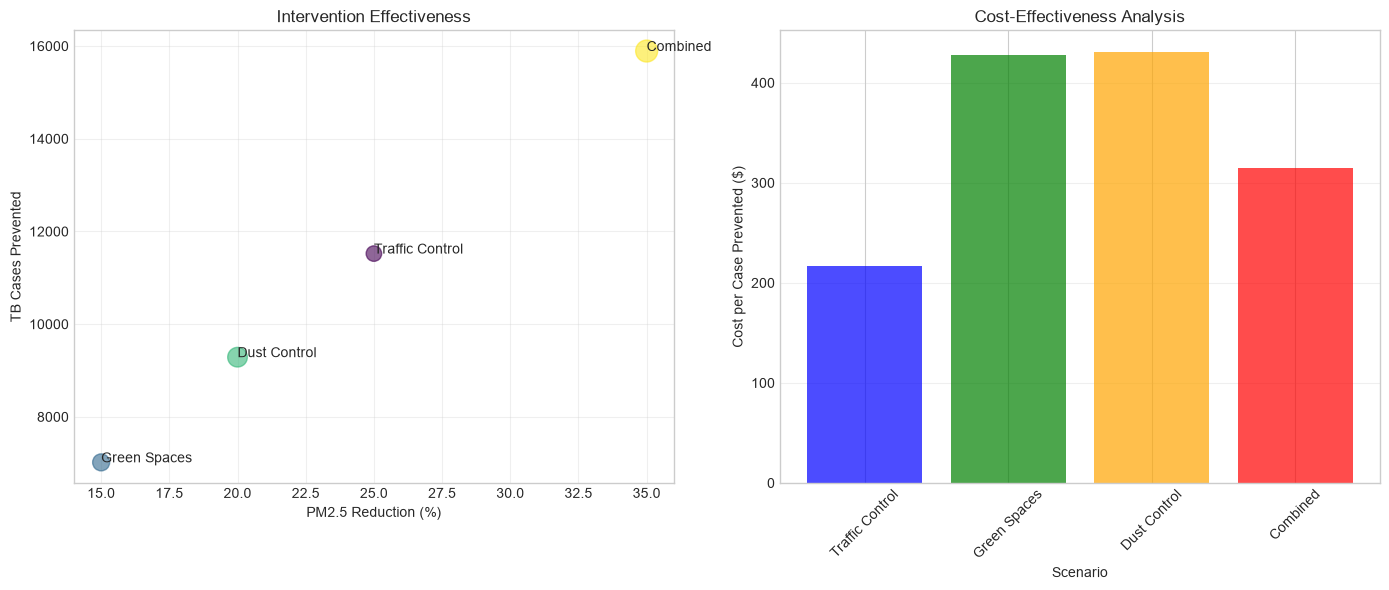

In [56]:
# Visualize intervention impacts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    results_df['PM2.5 Reduction (%)'],
    results_df['TB Cases Prevented'],
    s=results_df['Cost Factor'] * 50,
    alpha=0.6,
    c=range(len(results_df)),
    cmap='viridis'
)
for i, txt in enumerate(results_df['Scenario']):
    axes[0].annotate(
        txt,
        (
            results_df['PM2.5 Reduction (%)'].iloc[i],
            results_df['TB Cases Prevented'].iloc[i]
        )
    )
axes[0].set_xlabel('PM2.5 Reduction (%)')
axes[0].set_ylabel('TB Cases Prevented')
axes[0].set_title('Intervention Effectiveness')
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    results_df['Scenario'],
    results_df['Cost per Case Prevented ($)'],
    color=['blue', 'green', 'orange', 'red'],
    alpha=0.7
)
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Cost per Case Prevented ($)')
axes[1].set_title('Cost-Effectiveness Analysis')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Step 6: Generate Report


In [57]:
# Summary Report
print('=' * 72)
print('KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT')
print('=' * 72)
print()

print('1. DATA OVERVIEW')
print('-' * 40)
print(f"   - Analysis Period: {summary['date_range']}")
print(f"   - Total Records: {summary['total_records']}")
print(f"   - Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"   - Diseases modeled: {', '.join(disease_cols)}")
print()

print('2. TENSORFLOW FUSION MODEL RESULTS')
print('-' * 40)
if models_performance.empty:
    print('   - No disease models completed successfully.')
else:
    for _, row in models_performance.iterrows():
        print(
            f"   - {row['Disease']}: MAE={row['MAE']:.3f}, "
            f"RMSE={row['RMSE']:.3f}, R²={row['R²']:.3f}, "
            f"Train={int(row['Train Samples'])}, Test={int(row['Test Samples'])}"
        )
    best_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"   - Best disease by RMSE: {best_row['Disease']} "
        f"({best_row['RMSE']:.3f})"
    )
print()

print('3. TB INTERVENTION RECOMMENDATIONS')
print('-' * 40)
best_scenario = results_df.loc[results_df['TB Cases Prevented'].idxmax()]
print('   - Intervention simulation remains TB-specific.')
print(f"   - Most Effective: {best_scenario['Scenario']}")
print(f"   - PM2.5 Reduction: {best_scenario['PM2.5 Reduction (%)']:.1f}%")
print(f"   - TB Cases Prevented: {best_scenario['TB Cases Prevented']:.0f}")
print()

print('4. NOTES')
print('-' * 40)
print('   - Seasonal analysis now sits inside exploratory analysis.')
print('   - Spatial analysis combines Kampala divisions, PM2.5 monitors, and hospital records.')
print('   - The overall ITS visualization now sits inside time-series modeling.')
print('   - Each disease now uses its own TensorFlow fusion LSTM + dense regressor.')
print('=' * 72)


KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT

1. DATA OVERVIEW
----------------------------------------
   - Analysis Period: 2020-01-05 00:00:00 to 2024-12-15 00:00:00
   - Total Records: 248
   - Average PM2.5: 39.28 μg/m³
   - Diseases modeled: TB, ILI, ILD_deaths, pneumonia_u5, pneumonia_u5_deaths, SARI, SARI_deaths

2. TENSORFLOW FUSION MODEL RESULTS
----------------------------------------
   - SARI_deaths: MAE=2.991, RMSE=3.971, R²=-1.838, Train=12, Test=3
   - pneumonia_u5_deaths: MAE=4.060, RMSE=4.779, R²=-2.328, Train=60, Test=15
   - pneumonia_u5: MAE=170.498, RMSE=194.846, R²=-27.605, Train=188, Test=48
   - TB: MAE=219.242, RMSE=279.782, R²=-3.182, Train=188, Test=48
   - SARI: MAE=522.790, RMSE=594.244, R²=-16.429, Train=188, Test=48
   - ILI: MAE=1333.245, RMSE=1559.969, R²=-2.122, Train=185, Test=47
   - Best disease by RMSE: SARI_deaths (3.971)

3. TB INTERVENTION RECOMMENDATIONS
----------------------------------------
   - Intervention simulat

In [58]:
# Save downstream results
results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

notebook_tag = 'analysis'
results_df.to_csv(results_dir / f'{notebook_tag}_intervention_scenarios.csv', index=False)
models_performance.to_csv(results_dir / f'{notebook_tag}_model_performance.csv', index=False)

print(f"✓ Results saved to results/{notebook_tag}_intervention_scenarios.csv")
print(f"✓ Results saved to results/{notebook_tag}_model_performance.csv")


✓ Results saved to results/analysis_intervention_scenarios.csv
✓ Results saved to results/analysis_model_performance.csv
